# Importações por NCM 2024

Daniel da Cunha Costa - 2024006064

Isaac Reyes Alves de Abreu - 2025050342

Pedro Luiz Siva - 2024006129

In [1]:
import csv
import pandas as pd
import sqlite3

import requests
import seaborn as sns
import matplotlib.pyplot as plt

## Funções auxiliares

In [2]:
def fetch(query, conn, formated=True):
    """ 
        Executa uma query SQL em um banco de dados SQLite e retorna o resultado. 
        Converte o resultado em um DataFrame do Pandas se formated for True.
    """
    
    cur = conn.cursor()
    cur.execute(query)
    rs = cur.fetchall()

    columns = [description[0] for description in cur.description]
    return pd.DataFrame(rs, columns=columns) if formated else rs

def show_tables(conn):
    """ 
        Retorna os nomes das tabelas de um banco de dados SQLite. 
    """

    return [x[0] for x in fetch("SELECT name FROM sqlite_master WHERE type='table'", conn, formated=False)]

def shape(table, conn):
    """ 
        Retorna o numero de linhas e colunas de uma tabela SQLite.
    """

    nrows = fetch(f"SELECT COUNT(*) FROM {table}", conn, formated=False)[0][0]
    ncols = fetch(f"SELECT COUNT(*) FROM pragma_table_info('{table}')", conn, formated=False)[0][0]

    return (nrows, ncols)

def desc(table, conn):
    """ 
        Retorna os nomes das colunas de uma tabela SQLite.
    """
    cur = conn.cursor()
    cur.execute(f"PRAGMA table_info({table})")
    columns = [row[1] for row in cur.fetchall()]

    return columns

def info(table, conn):
    """ 
    Sumario resumido do esquema e perfil de dados de uma tabela SQLite. 
       """
    # table constraints (domain, null, default, pk)
    df1 = fetch(f'PRAGMA table_info("{table}")', conn)
    columns = desc(table, conn)
    
    # entries per column
    counts = ', '.join([f'COUNT(*) AS "{column}"' for column in columns])
    df2 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df2.columns = ['count']
    
    # non-null entries per column
    counts = ', '.join([f'COUNT("{column}") AS "{column}"' for column in columns])
    df3 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df3.columns = ['notnull count']

    # unique non-null entries per column
    counts = ', '.join([f'COUNT(DISTINCT "{column}") AS "{column}"' for column in columns])
    df4 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df4.columns = ['unique count']
    
    return df1.merge(df2, left_on='name', right_index=True) \
            .merge(df3, left_on='name', right_index=True) \
            .merge(df4, left_on='name', right_index=True)



# Dados

Source dataset: https://balanca.economia.gov.br/balanca/bd/comexstat-bd/ncm/IMP_2024.csv

In [3]:
# Carregamento e Análise Inicial dos Dados
import os
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Caminhos dos arquivos
data_path = "data/"
imp_file = os.path.join(data_path, "IMP_2024.csv")
aux_file = os.path.join(data_path, "TABELAS_AUXILIARES.xlsx")

print("📊 PLANO DE EDA - IMPORTAÇÕES NCM 2024")
print("="*60)
print("🎯 Objetivos da Análise:")
print("• Compreender o perfil das importações brasileiras por NCM")
print("• Identificar principais produtos, países e padrões temporais")
print("• Analisar distribuição de valores e quantidades")
print("• Detectar anomalias e insights estratégicos")
print("• Avaliar concentração de mercado e dependência comercial")
print("="*60)

📊 PLANO DE EDA - IMPORTAÇÕES NCM 2024
🎯 Objetivos da Análise:
• Compreender o perfil das importações brasileiras por NCM
• Identificar principais produtos, países e padrões temporais
• Analisar distribuição de valores e quantidades
• Detectar anomalias e insights estratégicos
• Avaliar concentração de mercado e dependência comercial


In [4]:
## 1. ANÁLISE ESTRUTURAL DOS DADOS

print("📁 Carregando dados de importações...")
print(f"Arquivo: {imp_file}")
print(f"Tamanho do arquivo: {os.path.getsize(imp_file) / (1024**2):.1f} MB")

# Carregamento otimizado do dataset principal
try:
    # Primeira leitura para entender estrutura
    df_sample = pd.read_csv(imp_file, nrows=1000, encoding='latin-1', sep=';')
    print(f"\n✅ Dataset carregado com sucesso!")
    print(f"📋 Colunas encontradas: {list(df_sample.columns)}")
    print(f"📐 Dimensões da amostra: {df_sample.shape}")
    
except Exception as e:
    print(f"❌ Erro no carregamento: {e}")
    # Tentativa com diferentes encodings
    for encoding in ['utf-8', 'iso-8859-1', 'cp1252']:
        try:
            df_sample = pd.read_csv(imp_file, nrows=1000, encoding=encoding, sep=';')
            print(f"✅ Sucesso com encoding: {encoding}")
            break
        except:
            continue

📁 Carregando dados de importações...
Arquivo: data/IMP_2024.csv
Tamanho do arquivo: 159.0 MB

✅ Dataset carregado com sucesso!
📋 Colunas encontradas: ['CO_ANO', 'CO_MES', 'CO_NCM', 'CO_UNID', 'CO_PAIS', 'SG_UF_NCM', 'CO_VIA', 'CO_URF', 'QT_ESTAT', 'KG_LIQUIDO', 'VL_FOB', 'VL_FRETE', 'VL_SEGURO']
📐 Dimensões da amostra: (1000, 13)


In [5]:
# Análise detalhada da estrutura
print("\n🔍 ANÁLISE ESTRUTURAL DETALHADA")
print("="*50)

# Informações básicas
print("📊 Tipos de dados:")
print(df_sample.dtypes)

print("\n📈 Estatísticas básicas:")
print(df_sample.describe(include='all'))

print("\n🔎 Primeiras linhas:")
display(df_sample.head())

print("\n❓ Valores ausentes:")
missing_data = df_sample.isnull().sum()
missing_pct = (missing_data / len(df_sample)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

display(missing_summary[missing_summary['Missing_Count'] > 0])

print("\n🆔 Valores únicos por coluna:")
for col in df_sample.columns:
    unique_count = df_sample[col].nunique()
    print(f"{col}: {unique_count:,} valores únicos")


🔍 ANÁLISE ESTRUTURAL DETALHADA
📊 Tipos de dados:
CO_ANO         int64
CO_MES         int64
CO_NCM         int64
CO_UNID        int64
CO_PAIS        int64
SG_UF_NCM     object
CO_VIA         int64
CO_URF         int64
QT_ESTAT       int64
KG_LIQUIDO     int64
VL_FOB         int64
VL_FRETE       int64
VL_SEGURO      int64
dtype: object

📈 Estatísticas básicas:
        CO_ANO       CO_MES        CO_NCM      CO_UNID      CO_PAIS SG_UF_NCM  \
count   1000.0  1000.000000  1.000000e+03  1000.000000  1000.000000      1000   
unique     NaN          NaN           NaN          NaN          NaN        23   
top        NaN          NaN           NaN          NaN          NaN        SP   
freq       NaN          NaN           NaN          NaN          NaN       398   
mean    2024.0     6.687000  7.058547e+07    10.497000   274.550000       NaN   
std        0.0     3.461649  2.168833e+07     0.838268   202.113729       NaN   
min     2024.0     1.000000  4.064000e+06    10.000000    23.000000    

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2024,10,84818092,11,161,SC,1,927800,344,90,6823,77,10
1,2024,4,90304090,11,249,SP,4,817700,1,9,4890,147,7
2,2024,1,39172300,10,23,PE,4,417901,1128,1128,28129,20688,7
3,2024,6,85444200,10,160,MG,4,817700,824,824,66958,11276,45
4,2024,10,84439942,10,190,SC,4,817600,3,3,2060,37,0



❓ Valores ausentes:


,Missing_Count,Missing_Percentage



🆔 Valores únicos por coluna:
CO_ANO: 1 valores únicos
CO_MES: 12 valores únicos
CO_NCM: 651 valores únicos
CO_UNID: 7 valores únicos
CO_PAIS: 60 valores únicos
SG_UF_NCM: 23 valores únicos
CO_VIA: 5 valores únicos
CO_URF: 32 valores únicos
QT_ESTAT: 666 valores únicos
KG_LIQUIDO: 663 valores únicos
VL_FOB: 958 valores únicos
VL_FRETE: 745 valores únicos
VL_SEGURO: 276 valores únicos


In [6]:
# Carregamento do dataset completo (com otimizações de memória)
print("\n⚡ Carregando dataset completo...")

# Definir tipos de dados para otimizar memória
dtype_dict = {}
for col in df_sample.columns:
    if df_sample[col].dtype == 'object':
        if df_sample[col].nunique() < 1000:  # Categorical para poucos valores únicos
            dtype_dict[col] = 'category'
        else:
            dtype_dict[col] = 'string'
    elif df_sample[col].dtype in ['int64', 'float64']:
        # Otimizar tipos numéricos
        if df_sample[col].min() >= 0:
            if df_sample[col].max() < 2**31:
                dtype_dict[col] = 'uint32'
            else:
                dtype_dict[col] = 'uint64'

print(f"📋 Tipos otimizados: {dtype_dict}")

# Carregamento completo
start_time = datetime.now()
df = pd.read_csv(imp_file, encoding='latin-1', sep=';', dtype=dtype_dict, low_memory=False)
load_time = (datetime.now() - start_time).total_seconds()

print(f"✅ Dataset carregado em {load_time:.1f} segundos")
print(f"📐 Dimensões finais: {df.shape}")
print(f"💾 Uso de memória: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")


⚡ Carregando dataset completo...
📋 Tipos otimizados: {'CO_ANO': 'uint32', 'CO_MES': 'uint32', 'CO_NCM': 'uint32', 'CO_UNID': 'uint32', 'CO_PAIS': 'uint32', 'SG_UF_NCM': 'category', 'CO_VIA': 'uint32', 'CO_URF': 'uint32', 'QT_ESTAT': 'uint32', 'KG_LIQUIDO': 'uint32', 'VL_FOB': 'uint32', 'VL_FRETE': 'uint32', 'VL_SEGURO': 'uint32'}
✅ Dataset carregado em 3.0 segundos
📐 Dimensões finais: (2273708, 13)
💾 Uso de memória: 106.3 MB


In [9]:
# Carregamento das tabelas auxiliares
print("\n📚 Carregando tabelas auxiliares...")
try:
    # Listar planilhas disponíveis
    xl_file = pd.ExcelFile(aux_file)
    print(f"📋 Planilhas disponíveis: {xl_file.sheet_names}")
    
    # Carregar todas as planilhas
    aux_tables = {}
    for sheet in xl_file.sheet_names:
        aux_tables[sheet] = pd.read_excel(aux_file, sheet_name=sheet)
        print(f"   • {sheet}: {aux_tables[sheet].shape}")
        
except Exception as e:
    print(f"⚠️ Erro ao carregar tabelas auxiliares: {e}")
    aux_tables = {}

print("\n🎯 RESUMO DO DATASET PRINCIPAL")
print("="*50)
print(f"📊 Total de registros: {len(df):,}")
print(f"📅 Período: 2024")
print(f"🏭 Total de códigos NCM únicos: {df['CO_NCM'].nunique() if 'CO_NCM' in df.columns else 'N/A'}")
print(f"🌍 Total de países: {df['CO_PAIS'].nunique() if 'CO_PAIS' in df.columns else 'N/A'}")

# Verificar colunas principais esperadas para análise NCM
expected_cols = ['CO_NCM', 'NO_NCM_POR', 'CO_PAIS', 'NO_PAIS', 'CO_MES', 'VL_FOB', 'QT_ESTAT', 'NO_UNID']
present_cols = [col for col in expected_cols if col in df.columns]
missing_cols = [col for col in expected_cols if col not in df.columns]

print(f"\n✅ Colunas principais presentes: {present_cols}")
if missing_cols:
    print(f"❌ Colunas esperadas ausentes: {missing_cols}")
    
print(f"\n📋 Todas as colunas disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")


📚 Carregando tabelas auxiliares...
📋 Planilhas disponíveis: ['ÍNDICE', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
   • ÍNDICE: (16, 5)
   • 1: (13721, 18)
   • 2: (13721, 12)
   • 3: (13721, 14)
   • 4: (13721, 18)
   • 5: (13418, 4)
   • 6: (13721, 5)
   • 7: (13700, 5)
   • 8: (13418, 6)
   • 9: (13418, 6)
   • 10: (281, 6)
   • 11: (322, 5)
   • 12: (34, 4)
   • 13: (5570, 4)
   • 14: (17, 2)
   • 15: (279, 2)
   • 16: (13721, 6)

🎯 RESUMO DO DATASET PRINCIPAL
📊 Total de registros: 2,273,708
📅 Período: 2024
🏭 Total de códigos NCM únicos: 8748
🌍 Total de países: 239

✅ Colunas principais presentes: ['CO_NCM', 'CO_PAIS', 'CO_MES', 'VL_FOB', 'QT_ESTAT']
❌ Colunas esperadas ausentes: ['NO_NCM_POR', 'NO_PAIS', 'NO_UNID']

📋 Todas as colunas disponíveis:
    1. CO_ANO
    2. CO_MES
    3. CO_NCM
    4. CO_UNID
    5. CO_PAIS
    6. SG_UF_NCM
    7. CO_VIA
    8. CO_URF
    9. QT_ESTAT
   10. KG_LIQUIDO
   11. VL_FOB
   12. VL_FRETE
   13. VL_SE

In [10]:
# Análise das tabelas auxiliares para identificar estrutura
print("\n🔍 ANÁLISE DAS TABELAS AUXILIARES")
print("="*50)

# Verificar o índice para entender a estrutura
if 'ÍNDICE' in aux_tables:
    print("📋 Estrutura do índice:")
    display(aux_tables['ÍNDICE'])

# Examinar algumas planilhas principais
sample_sheets = ['10', '11', '13', '15']  # Planilhas que podem conter países, NCM, unidades
for sheet in sample_sheets:
    if sheet in aux_tables:
        print(f"\n📊 Planilha {sheet} (primeiras 5 linhas):")
        display(aux_tables[sheet].head())
        print(f"Colunas: {list(aux_tables[sheet].columns)}")

# Tentar identificar tabela de países (geralmente tem CO_PAIS e NO_PAIS)
pais_table = None
for sheet_name, table in aux_tables.items():
    if 'CO_PAIS' in table.columns and 'NO_PAIS' in table.columns:
        pais_table = table
        print(f"\n🌍 Tabela de países encontrada na planilha: {sheet_name}")
        print(f"Total de países: {len(table)}")
        display(table.head())
        break

# Tentar identificar tabela de NCM
ncm_table = None
for sheet_name, table in aux_tables.items():
    if 'CO_NCM' in table.columns and any('NCM' in col or 'DESCR' in col.upper() for col in table.columns):
        ncm_table = table
        print(f"\n🏷️ Tabela de NCM encontrada na planilha: {sheet_name}")
        print(f"Total de NCMs: {len(table)}")
        print(f"Colunas: {list(table.columns)}")
        display(table.head())
        break

# Tentar identificar tabela de unidades
unid_table = None
for sheet_name, table in aux_tables.items():
    if 'CO_UNID' in table.columns and any('UNID' in col.upper() or 'DESCR' in col.upper() for col in table.columns):
        unid_table = table
        print(f"\n📏 Tabela de unidades encontrada na planilha: {sheet_name}")
        print(f"Total de unidades: {len(table)}")
        display(table.head())
        break


🔍 ANÁLISE DAS TABELAS AUXILIARES
📋 Estrutura do índice:


,Número da aba,Nome,Descrição,Arquivo Referência,Chave de cruzamento
0,1,SH - Sistema Harmonizado,Códigos e descrições do Sistema Harmonizado (S...,NCM_SH.csv,CO_SH6
1,2,CUCI - Classificação Uniforme para Comércio In...,Códigos e descrições dos níveis da classificaç...,NCM_CUCI.csv,CO_CUCI
2,3,CGCE - Classificação por Grandes Categorias Ec...,Códigos e descrições dos níveis da classificaç...,NCM_CGCE.csv,CO_CGCE_N3
3,4,ISIC - International Standard Industrial Class...,Códigos e descrições da classificação ISIC (Re...,NCM_ISIC.csv,CO_ISIC_CLASSE
4,5,SIIT - Setores Industriais por Intensidade Tec...,Códigos e descrições da classificação SIIT.,NCM_SIIT.csv,CO_SIIT
5,6,Unidade Estatística da NCM,Códigos e descrições das unidades estatísticas...,NCM_UNIDADE.csv,CO_UNID
6,7,Fator Agregado da NCM - Classificação própria ...,Códigos e descrições de Fator Agregado das NCM...,NCM_FAT_AGREG.csv,CO_FAT_AGREG
7,8,Pauta de Produtos Importados - Classificação p...,Códigos e descrições da Pauta de Produtos Impo...,NCM_PPI.csv,CO_PPI
8,9,Pauta de Produtos Exportados - Classificação p...,Códigos e descrições da Pauta de Produtos Expo...,NCM_PPE.csv,CO_PPE
9,10,Países,Códigos e descrições de países.,PAIS.csv,CO_PAIS



📊 Planilha 10 (primeiras 5 linhas):


,CO_PAIS,CO_PAIS_ISON3,CO_PAIS_ISOA3,NO_PAIS,NO_PAIS_ING,NO_PAIS_ESP
0,0,898,ZZZ,Não Definido,Not defined,No definido
1,13,4,AFG,Afeganistão,Afghanistan,Afganistan
2,15,248,ALA,"Aland, Ilhas",Aland Islands,"Alans, Islas"
3,17,8,ALB,Albânia,Albania,Albania
4,20,724,ESP,"Alboran-Perejil, Ilhas","Alboran-Perejil, Islands","Alboran-Perejil, Islas"


Colunas: ['CO_PAIS', 'CO_PAIS_ISON3', 'CO_PAIS_ISOA3', 'NO_PAIS', 'NO_PAIS_ING', 'NO_PAIS_ESP']

📊 Planilha 11 (primeiras 5 linhas):


...

,CO_PAIS,CO_PAIS_ISON3,CO_PAIS_ISOA3,NO_PAIS,NO_PAIS_ING,NO_PAIS_ESP
0,0,898,ZZZ,Não Definido,Not defined,No definido
1,13,4,AFG,Afeganistão,Afghanistan,Afganistan
2,15,248,ALA,"Aland, Ilhas",Aland Islands,"Alans, Islas"
3,17,8,ALB,Albânia,Albania,Albania
4,20,724,ESP,"Alboran-Perejil, Ilhas","Alboran-Perejil, Islands","Alboran-Perejil, Islas"



🏷️ Tabela de NCM encontrada na planilha: 1
Total de NCMs: 13721
Colunas: ['CO_NCM', 'NO_NCM_POR', 'CO_SH6', 'NO_SH6_POR', 'NO_SH6_ESP', 'NO_SH6_ING', 'CO_SH4', 'NO_SH4_POR', 'NO_SH4_ESP', 'NO_SH4_ING', 'CO_SH2', 'NO_SH2_POR', 'NO_SH2_ESP', 'NO_SH2_ING', 'CO_NCM_SECROM', 'NO_SEC_POR', 'NO_SEC_ESP', 'NO_SEC_ING']


,CO_NCM,NO_NCM_POR,CO_SH6,NO_SH6_POR,NO_SH6_ESP,NO_SH6_ING,CO_SH4,NO_SH4_POR,NO_SH4_ESP,NO_SH4_ING,CO_SH2,NO_SH2_POR,NO_SH2_ESP,NO_SH2_ING,CO_NCM_SECROM,NO_SEC_POR,NO_SEC_ESP,NO_SEC_ING
0,1011010,Cavalos reprodutores de raça pura,10110,"Animais vivos das espécies cavalar, asinina e ...","Caballos y asnos, reproductores de raza pura",Pure-bred breeding horses and asses,101,"Cavalos, asininos e muares, vivos","Caballos, asnos, mulos y burdéganos, vivos","Live horses, asses, mules and hinnies",1,Animais vivos,Animales vivos,Live animals,I,Animais vivos e produtos do reino animal,Animales vivos y productos del reino animal,Lives animals; Animal products
1,1011090,"Animais da espécie asinina/muar, reprodutores,...",10110,"Animais vivos das espécies cavalar, asinina e ...","Caballos y asnos, reproductores de raza pura",Pure-bred breeding horses and asses,101,"Cavalos, asininos e muares, vivos","Caballos, asnos, mulos y burdéganos, vivos","Live horses, asses, mules and hinnies",1,Animais vivos,Animales vivos,Live animals,I,Animais vivos e produtos do reino animal,Animales vivos y productos del reino animal,Lives animals; Animal products
2,1011100,"Cavalos reprodutores, de raça pura",10111,"Cavalos reprodutores, de raça pura",Caballos reproductores de raza pura,Pure-bred breeding horses,101,"Cavalos, asininos e muares, vivos","Caballos, asnos, mulos y burdéganos, vivos","Live horses, asses, mules and hinnies",1,Animais vivos,Animales vivos,Live animals,I,Animais vivos e produtos do reino animal,Animales vivos y productos del reino animal,Lives animals; Animal products
3,1011900,"Outros cavalos, vivos",10119,"Outros cavalos, vivos","Demás caballos, vivos",Other live horses,101,"Cavalos, asininos e muares, vivos","Caballos, asnos, mulos y burdéganos, vivos","Live horses, asses, mules and hinnies",1,Animais vivos,Animales vivos,Live animals,I,Animais vivos e produtos do reino animal,Animales vivos y productos del reino animal,Lives animals; Animal products
4,1012000,Asininos e muares vivos,10120,Asininos e muares vivos,"Asnos, mulos y burdéganos, vivos","Asses, mules and hinnies (live)",101,"Cavalos, asininos e muares, vivos","Caballos, asnos, mulos y burdéganos, vivos","Live horses, asses, mules and hinnies",1,Animais vivos,Animales vivos,Live animals,I,Animais vivos e produtos do reino animal,Animales vivos y productos del reino animal,Lives animals; Animal products



📏 Tabela de unidades encontrada na planilha: 6
Total de unidades: 13721


,CO_NCM,NO_NCM_POR,CO_UNID,NO_UNID,SG_UNID
0,1011010,Cavalos reprodutores de raça pura,11,NUMERO (UNIDADE),UNID.
1,1011090,"Animais da espécie asinina/muar, reprodutores,...",11,NUMERO (UNIDADE),UNID.
2,1011100,"Cavalos reprodutores, de raça pura",11,NUMERO (UNIDADE),UNID.
3,1011900,"Outros cavalos, vivos",11,NUMERO (UNIDADE),UNID.
4,1012000,Asininos e muares vivos,11,NUMERO (UNIDADE),UNID.


In [12]:
# Criar dataset enriquecido de forma mais eficiente para evitar erro de memória
print("\n🔗 CRIANDO DATASET ENRIQUECIDO (OTIMIZADO)")
print("="*50)

# Usar apenas as tabelas mais importantes para evitar problemas de memória
df_enriched = df.copy()

# 1. Merge com tabela de países (planilha 10) - Mais importante
if 'CO_PAIS' in aux_tables['10'].columns:
    print("🌍 Processando merge com países...")
    pais_lookup = aux_tables['10'][['CO_PAIS', 'NO_PAIS']].copy()
    df_enriched = df_enriched.merge(pais_lookup, on='CO_PAIS', how='left')
    print(f"✅ Merge com países: {df_enriched['NO_PAIS'].notna().sum():,} registros com nome do país")

# 2. Merge com tabela de NCM (planilha 1) - Mais importante  
if 'CO_NCM' in aux_tables['1'].columns:
    print("🏷️ Processando merge com NCM...")
    ncm_lookup = aux_tables['1'][['CO_NCM', 'NO_NCM_POR', 'NO_SEC_POR']].copy()
    df_enriched = df_enriched.merge(ncm_lookup, on='CO_NCM', how='left')
    print(f"✅ Merge com NCM: {df_enriched['NO_NCM_POR'].notna().sum():,} registros com descrição NCM")

# 3. Criar lookup tables separadas para uso posterior (evitando merge pesado)
print("📋 Criando tabelas de lookup separadas...")

# Lookup de unidades
if 'CO_UNID' in aux_tables['6'].columns:
    unidades_lookup = aux_tables['6'][['CO_UNID', 'NO_UNID']].set_index('CO_UNID')['NO_UNID'].to_dict()
    df_enriched['NO_UNID'] = df_enriched['CO_UNID'].map(unidades_lookup)
    print(f"✅ Lookup unidades: {df_enriched['NO_UNID'].notna().sum():,} registros com nome da unidade")

# Lookup de URF  
if 'CO_URF' in aux_tables['15'].columns:
    urf_lookup = aux_tables['15'][['CO_URF', 'NO_URF']].set_index('CO_URF')['NO_URF'].to_dict()
    df_enriched['NO_URF'] = df_enriched['CO_URF'].map(urf_lookup)
    print(f"✅ Lookup URF: {df_enriched['NO_URF'].notna().sum():,} registros com nome da URF")

print(f"\n📊 Dataset enriquecido criado:")
print(f"   • Dimensões: {df_enriched.shape}")
print(f"   • Uso de memória: {df_enriched.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

# Verificar qualidade dos merges
print(f"\n🔍 QUALIDADE DO ENRIQUECIMENTO:")
quality_stats = {
    'Total_Registros': len(df_enriched),
    'Com_Nome_Pais': df_enriched['NO_PAIS'].notna().sum(),
    'Com_Desc_NCM': df_enriched['NO_NCM_POR'].notna().sum(),
    'Com_Nome_Unidade': df_enriched['NO_UNID'].notna().sum() if 'NO_UNID' in df_enriched.columns else 0,
    'Com_Nome_URF': df_enriched['NO_URF'].notna().sum() if 'NO_URF' in df_enriched.columns else 0
}

for key, value in quality_stats.items():
    if key != 'Total_Registros' and value > 0:
        percentage = (value / quality_stats['Total_Registros']) * 100
        print(f"   • {key}: {percentage:.1f}% dos registros")

# Mostrar amostra do dataset enriquecido
print(f"\n📋 AMOSTRA DO DATASET ENRIQUECIDO:")
sample_cols = ['CO_NCM', 'NO_NCM_POR', 'CO_PAIS', 'NO_PAIS', 'VL_FOB', 'QT_ESTAT', 'NO_UNID']
available_cols = [col for col in sample_cols if col in df_enriched.columns]
display(df_enriched[available_cols].head(10))

# Atualizar variável principal (de forma mais cuidadosa)
print(f"\n🔄 Atualizando dataset principal...")
df = df_enriched
print(f"✅ Dataset principal atualizado com informações enriquecidas!")
print(f"   • Agora temos nomes de países e descrições de NCM!")


🔗 CRIANDO DATASET ENRIQUECIDO (OTIMIZADO)
🌍 Processando merge com países...
✅ Merge com países: 2,273,708 registros com nome do país
🏷️ Processando merge com NCM...
✅ Merge com NCM: 2,273,708 registros com descrição NCM
📋 Criando tabelas de lookup separadas...
✅ Lookup unidades: 2,273,708 registros com nome da unidade
✅ Lookup URF: 2,273,708 registros com nome da URF

📊 Dataset enriquecido criado:
   • Dimensões: (2273708, 18)
   • Uso de memória: 1246.0 MB

🔍 QUALIDADE DO ENRIQUECIMENTO:
   • Com_Nome_Pais: 100.0% dos registros
   • Com_Desc_NCM: 100.0% dos registros
   • Com_Nome_Unidade: 100.0% dos registros
   • Com_Nome_URF: 100.0% dos registros

📋 AMOSTRA DO DATASET ENRIQUECIDO:


,CO_NCM,NO_NCM_POR,CO_PAIS,NO_PAIS,VL_FOB,QT_ESTAT,NO_UNID
0,84818092,Válvulas solenóides,161,Taiwan (Formosa),6823,344,NUMERO (UNIDADE)
1,90304090,Outros instrumentos e aparelhos para telecomun...,249,Estados Unidos,4890,1,NUMERO (UNIDADE)
2,39172300,"Tubo rígido, de polímeros de cloreto de vinila",23,Alemanha,28129,1128,QUILOGRAMA LIQUIDO
3,85444200,"Outros condutores elétricos tensão <= 100 v, c...",160,China,66958,824,QUILOGRAMA LIQUIDO
4,84439942,Outras cabeças de impressão,190,Coreia do Sul,2060,3,QUILOGRAMA LIQUIDO
5,39174090,"Outros acessórios para tubos, de plásticos",160,China,29390,1570,QUILOGRAMA LIQUIDO
6,85129000,Partes de aparelhos elétricos de iluminação ou...,249,Estados Unidos,262213,11994,QUILOGRAMA LIQUIDO
7,90301010,Medidores de radioatividade,249,Estados Unidos,5358,1,NUMERO (UNIDADE)
8,82130000,"Tesouras e suas lâminas, de metais comuns",160,China,176021,30632,QUILOGRAMA LIQUIDO
9,84813000,Válvulas de retenção,160,China,63213,15750,NUMERO (UNIDADE)



🔄 Atualizando dataset principal...
✅ Dataset principal atualizado com informações enriquecidas!
   • Agora temos nomes de países e descrições de NCM!


## 2. ANÁLISE DE QUALIDADE DOS DADOS

Esta seção examina a qualidade, consistência e integridade dos dados de importação, identificando possíveis problemas que possam afetar a análise.

In [13]:
print("🔍 ANÁLISE DE QUALIDADE DOS DADOS")
print("="*50)

# 1. Análise de Valores Ausentes
print("\n📊 1. VALORES AUSENTES")
missing_analysis = pd.DataFrame({
    'Total_Missing': df.isnull().sum(),
    'Percent_Missing': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
}).sort_values('Total_Missing', ascending=False)

print(missing_analysis[missing_analysis['Total_Missing'] > 0])

# 2. Análise de Duplicados
print(f"\n🔄 2. REGISTROS DUPLICADOS")
duplicates = df.duplicated().sum()
print(f"Total de duplicados: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

if duplicates > 0:
    # Análise mais detalhada de duplicados
    duplicate_subset = ['CO_NCM', 'CO_PAIS', 'CO_MES'] if all(col in df.columns for col in ['CO_NCM', 'CO_PAIS', 'CO_MES']) else None
    if duplicate_subset:
        business_duplicates = df.duplicated(subset=duplicate_subset).sum()
        print(f"Duplicados por chave de negócio (NCM+País+Mês): {business_duplicates:,}")

# 3. Análise de Valores Extremos/Inválidos
print(f"\n⚠️ 3. ANÁLISE DE CONSISTÊNCIA")

# Verificar valores negativos em campos que deveriam ser positivos
value_cols = [col for col in ['VL_FOB', 'QT_ESTAT'] if col in df.columns]
for col in value_cols:
    if df[col].dtype in ['int64', 'float64', 'uint32', 'uint64']:
        negative_count = (df[col] < 0).sum()
        zero_count = (df[col] == 0).sum()
        print(f"{col}:")
        print(f"  • Valores negativos: {negative_count:,}")
        print(f"  • Valores zero: {zero_count:,}")
        print(f"  • Min: {df[col].min():,.2f}, Max: {df[col].max():,.2f}")

# 4. Análise de códigos NCM
if 'CO_NCM' in df.columns:
    print(f"\n🏷️ 4. ANÁLISE DE CÓDIGOS NCM")
    ncm_length_analysis = df['CO_NCM'].astype(str).str.len().value_counts().sort_index()
    print("Distribuição por tamanho de código NCM:")
    print(ncm_length_analysis)
    
    # Verificar se todos são códigos de 8 dígitos
    invalid_ncm = df[df['CO_NCM'].astype(str).str.len() != 8]
    print(f"Códigos NCM inválidos (≠ 8 dígitos): {len(invalid_ncm):,}")

# 5. Análise temporal
if 'CO_MES' in df.columns:
    print(f"\n📅 5. ANÁLISE TEMPORAL")
    month_dist = df['CO_MES'].value_counts().sort_index()
    print("Distribuição por mês:")
    print(month_dist)
    
    # Verificar se há meses inválidos
    invalid_months = df[(df['CO_MES'] < 1) | (df['CO_MES'] > 12)]['CO_MES'].value_counts()
    if len(invalid_months) > 0:
        print(f"⚠️ Meses inválidos encontrados: {invalid_months}")

print("\n✅ Análise de qualidade concluída!")

🔍 ANÁLISE DE QUALIDADE DOS DADOS

📊 1. VALORES AUSENTES
Empty DataFrame
Columns: [Total_Missing, Percent_Missing, Data_Type]
Index: []

🔄 2. REGISTROS DUPLICADOS
Total de duplicados: 0 (0.00%)

⚠️ 3. ANÁLISE DE CONSISTÊNCIA
VL_FOB:
  • Valores negativos: 0
  • Valores zero: 3,217
  • Min: 0.00, Max: 545,738,786.00
QT_ESTAT:
  • Valores negativos: 0
  • Valores zero: 160,136
  • Min: 0.00, Max: 1,358,632,353.00

🏷️ 4. ANÁLISE DE CÓDIGOS NCM
Distribuição por tamanho de código NCM:
CO_NCM
7      18295
8    2255413
Name: count, dtype: int64
Códigos NCM inválidos (≠ 8 dígitos): 18,295

📅 5. ANÁLISE TEMPORAL
Distribuição por mês:
CO_MES
1     183980
2     177257
3     179226
4     194289
5     182010
6     182203
7     195554
8     195362
9     193427
10    201639
11    194477
12    194284
Name: count, dtype: int64

✅ Análise de qualidade concluída!


## 3. ANÁLISE DESCRITIVA DAS IMPORTAÇÕES

### 3.1 Panorama Geral das Importações Brasileiras 2024

Esta seção apresenta uma visão abrangente do perfil das importações brasileiras, analisando volumes, valores e padrões de concentração.

In [14]:
print("📊 PANORAMA GERAL DAS IMPORTAÇÕES BRASILEIRAS 2024")
print("="*60)

# Verificar se as colunas principais existem
vl_col = 'VL_FOB' if 'VL_FOB' in df.columns else None
qt_col = 'QT_ESTAT' if 'QT_ESTAT' in df.columns else None

if vl_col:
    # Estatísticas gerais de valor
    total_value = df[vl_col].sum()
    mean_value = df[vl_col].mean()
    median_value = df[vl_col].median()
    
    print(f"💰 VALOR TOTAL IMPORTADO")
    print(f"   • Total: US$ {total_value:,.2f}")
    print(f"   • Média por operação: US$ {mean_value:,.2f}")
    print(f"   • Mediana: US$ {median_value:,.2f}")
    
    # Distribuição de valores
    print(f"\n📈 DISTRIBUIÇÃO DE VALORES")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        value = np.percentile(df[vl_col], p)
        print(f"   • P{p}: US$ {value:,.2f}")

if qt_col:
    print(f"\n📦 QUANTIDADE ESTATÍSTICA")
    total_qty = df[qt_col].sum()
    print(f"   • Total: {total_qty:,.0f} unidades")

# Contagens gerais
print(f"\n🔢 CONTAGENS GERAIS")
print(f"   • Total de operações: {len(df):,}")
print(f"   • Códigos NCM únicos: {df['CO_NCM'].nunique() if 'CO_NCM' in df.columns else 'N/A'}")
print(f"   • Países fornecedores: {df['CO_PAIS'].nunique() if 'CO_PAIS' in df.columns else 'N/A'}")
print(f"   • Unidades de medida: {df['NO_UNID'].nunique() if 'NO_UNID' in df.columns else 'N/A'}")

# Análise de concentração
if vl_col and 'CO_NCM' in df.columns:
    print(f"\n🎯 ANÁLISE DE CONCENTRAÇÃO")
    
    # Concentração por NCM (Top 10)
    top_ncm = df.groupby('CO_NCM')[vl_col].sum().sort_values(ascending=False).head(10)
    top_ncm_share = (top_ncm.sum() / total_value) * 100
    
    print(f"   • Top 10 NCMs representam: {top_ncm_share:.1f}% do valor total")
    
    # Índice de Herfindahl-Hirschman para NCM
    ncm_shares = (df.groupby('CO_NCM')[vl_col].sum() / total_value) ** 2
    hhi_ncm = ncm_shares.sum() * 10000  # Multiplicado por 10000 para escala tradicional
    print(f"   • Índice HHI para NCM: {hhi_ncm:.0f}")
    
    concentration_level = "Alta" if hhi_ncm > 2500 else "Moderada" if hhi_ncm > 1500 else "Baixa"
    print(f"   • Concentração de mercado: {concentration_level}")

if vl_col and 'CO_PAIS' in df.columns:
    # Concentração por país
    top_countries = df.groupby('CO_PAIS')[vl_col].sum().sort_values(ascending=False).head(10)
    top_countries_share = (top_countries.sum() / total_value) * 100
    print(f"   • Top 10 países representam: {top_countries_share:.1f}% do valor total")

📊 PANORAMA GERAL DAS IMPORTAÇÕES BRASILEIRAS 2024
💰 VALOR TOTAL IMPORTADO
   • Total: US$ 262,869,606,174.00
   • Média por operação: US$ 115,612.74
   • Mediana: US$ 3,696.00

📈 DISTRIBUIÇÃO DE VALORES
   • P10: US$ 85.00
   • P25: US$ 495.00
   • P50: US$ 3,696.00
   • P75: US$ 27,040.00
   • P90: US$ 124,460.00
   • P95: US$ 298,112.20
   • P99: US$ 1,564,310.03

📦 QUANTIDADE ESTATÍSTICA
   • Total: 283,510,891,558 unidades

🔢 CONTAGENS GERAIS
   • Total de operações: 2,273,708
   • Códigos NCM únicos: 8748
   • Países fornecedores: 239
   • Unidades de medida: 13

🎯 ANÁLISE DE CONCENTRAÇÃO
   • Top 10 NCMs representam: 16.6% do valor total
   • Índice HHI para NCM: 50
   • Concentração de mercado: Baixa
   • Top 10 países representam: 65.9% do valor total


In [15]:
### 3.2 Rankings dos Principais Produtos e Países

print("\n🏆 TOP RANKINGS DE IMPORTAÇÃO")
print("="*50)

if vl_col and 'CO_NCM' in df.columns:
    # Top NCMs por valor
    print("\n💎 TOP 15 CÓDIGOS NCM POR VALOR")
    top_ncm_detailed = df.groupby(['CO_NCM', 'NO_NCM_POR']).agg({
        vl_col: ['sum', 'count'],
        qt_col: 'sum' if qt_col else None
    }).round(2)
    
    # Flatten column names
    top_ncm_detailed.columns = ['_'.join(col).strip() if col[1] else col[0] for col in top_ncm_detailed.columns]
    top_ncm_detailed = top_ncm_detailed.sort_values(f'{vl_col}_sum', ascending=False).head(15)
    
    # Calcular participação percentual
    top_ncm_detailed['Participacao_%'] = (top_ncm_detailed[f'{vl_col}_sum'] / total_value * 100).round(2)
    
    print(top_ncm_detailed)

if vl_col and 'CO_PAIS' in df.columns:
    # Top países por valor
    print(f"\n🌍 TOP 15 PAÍSES FORNECEDORES POR VALOR")
    top_countries_detailed = df.groupby(['CO_PAIS', 'NO_PAIS']).agg({
        vl_col: ['sum', 'count', 'mean'],
        'CO_NCM': 'nunique'
    }).round(2)
    
    # Flatten column names  
    top_countries_detailed.columns = ['_'.join(col).strip() if col[1] else col[0] for col in top_countries_detailed.columns]
    top_countries_detailed = top_countries_detailed.sort_values(f'{vl_col}_sum', ascending=False).head(15)
    
    # Calcular participação percentual
    top_countries_detailed['Participacao_%'] = (top_countries_detailed[f'{vl_col}_sum'] / total_value * 100).round(2)
    
    print(top_countries_detailed)

# Análise de unidades de medida
if 'NO_UNID' in df.columns and vl_col:
    print(f"\n📏 PRINCIPAIS UNIDADES DE MEDIDA")
    units_analysis = df.groupby('NO_UNID').agg({
        vl_col: 'sum',
        'CO_NCM': 'nunique',
        vl_col: 'count'
    }).sort_values(vl_col, ascending=False).head(10)
    
    units_analysis['Participacao_%'] = (units_analysis[vl_col] / total_value * 100).round(2)
    print(units_analysis)

# Análise temporal mensal
if 'CO_MES' in df.columns and vl_col:
    print(f"\n📅 DISTRIBUIÇÃO MENSAL DAS IMPORTAÇÕES")
    monthly_analysis = df.groupby('CO_MES').agg({
        vl_col: ['sum', 'mean', 'count'],
        'CO_NCM': 'nunique',
        'CO_PAIS': 'nunique'
    }).round(2)
    
    # Flatten column names
    monthly_analysis.columns = ['_'.join(col).strip() if col[1] else col[0] for col in monthly_analysis.columns]
    
    # Adicionar nomes dos meses
    month_names = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
                   7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
    monthly_analysis['Mes_Nome'] = monthly_analysis.index.map(month_names)
    
    print(monthly_analysis)


🏆 TOP RANKINGS DE IMPORTAÇÃO

💎 TOP 15 CÓDIGOS NCM POR VALOR
                                                             VL_FOB_sum  \
CO_NCM   NO_NCM_POR                                                       
27090010 Óleos brutos de petróleo                            8690210062   
27101921 Gasóleo (óleo diesel)                               8359492092   
84119100 Partes de turborreatores ou de turbopropulsores     4837676499   
31042090 Outros cloretos de potássio                         3606983824   
84111200 Turborreatores de empuxo superior a 25 kN           3418099488   
30021590 Outros produtos imunológicos, apresentados em d...  3320554118   
87042190 Outros veículos automóveis com motor diesel, pa...  3264984879   
27011200 Hulha betuminosa, não aglomerada                    2837201476   
31021010 Ureia, mesmo em solução aquosa, com teor de nit...  2687692092   
27101241 Naftas para petroquimica                            2628440404   
85414300 Células fotovoltaicas montada

## 4. ANÁLISE VISUAL E EXPLORATÓRIA

### 4.1 Visualizações dos Principais Padrões de Importação

📊 CRIANDO VISUALIZAÇÕES DOS DADOS DE IMPORTAÇÃO


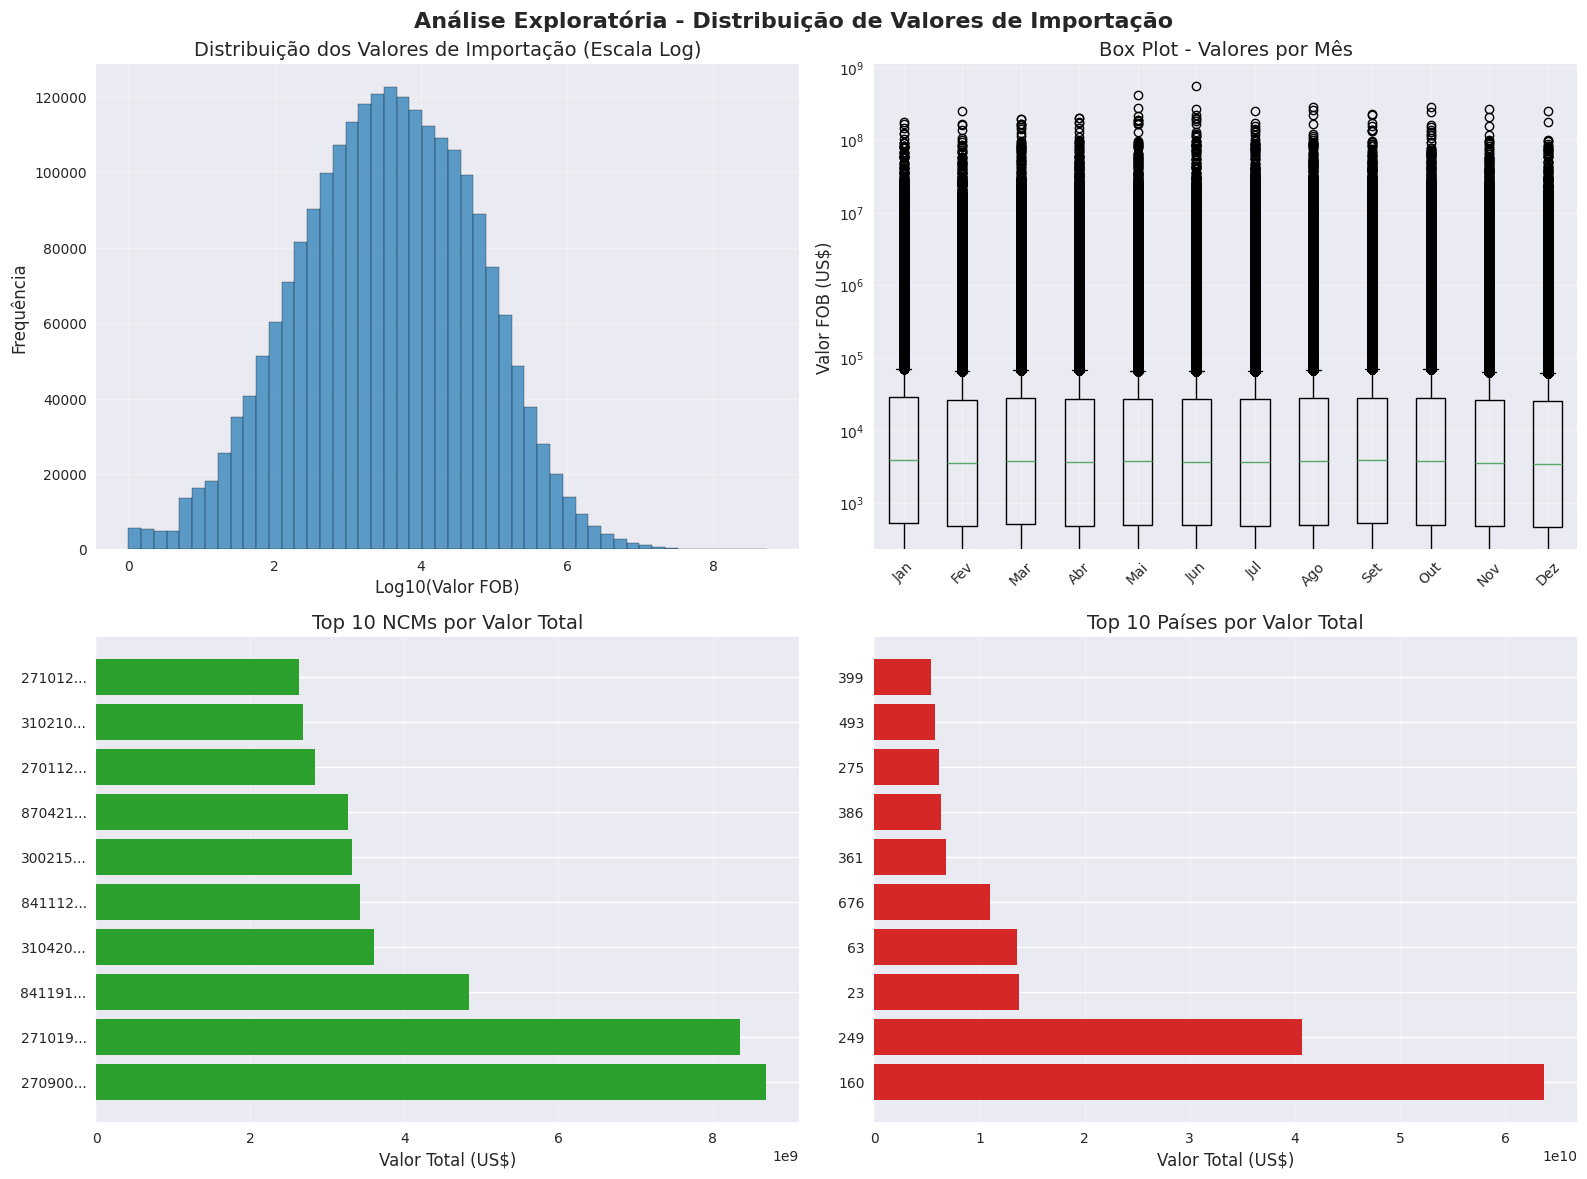

✅ Primeiras visualizações criadas!


In [16]:
# Configurações para visualizações
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Cores personalizadas
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

print("📊 CRIANDO VISUALIZAÇÕES DOS DADOS DE IMPORTAÇÃO")
print("="*55)

# 1. Distribuição de Valores de Importação
if vl_col:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise Exploratória - Distribuição de Valores de Importação', fontsize=16, fontweight='bold')
    
    # Histograma dos valores (log scale)
    values_log = np.log10(df[vl_col][df[vl_col] > 0])
    ax1.hist(values_log, bins=50, alpha=0.7, color=colors[0], edgecolor='black')
    ax1.set_xlabel('Log10(Valor FOB)')
    ax1.set_ylabel('Frequência')
    ax1.set_title('Distribuição dos Valores de Importação (Escala Log)')
    ax1.grid(True, alpha=0.3)
    
    # Box plot dos valores por mês
    if 'CO_MES' in df.columns:
        monthly_values = [df[df['CO_MES'] == month][vl_col].values for month in range(1, 13)]
        month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
        
        ax2.boxplot(monthly_values, labels=month_labels)
        ax2.set_ylabel('Valor FOB (US$)')
        ax2.set_title('Box Plot - Valores por Mês')
        ax2.tick_params(axis='x', rotation=45)
        ax2.set_yscale('log')
        ax2.grid(True, alpha=0.3)
    
    # Top 10 NCMs
    top_ncm_plot = df.groupby('CO_NCM')[vl_col].sum().sort_values(ascending=False).head(10)
    ax3.barh(range(len(top_ncm_plot)), top_ncm_plot.values, color=colors[2])
    ax3.set_yticks(range(len(top_ncm_plot)))
    ax3.set_yticklabels([str(ncm)[:6] + '...' for ncm in top_ncm_plot.index])
    ax3.set_xlabel('Valor Total (US$)')
    ax3.set_title('Top 10 NCMs por Valor Total')
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Top 10 Países
    if 'CO_PAIS' in df.columns:
        top_countries_plot = df.groupby('CO_PAIS')[vl_col].sum().sort_values(ascending=False).head(10)
        ax4.barh(range(len(top_countries_plot)), top_countries_plot.values, color=colors[3])
        ax4.set_yticks(range(len(top_countries_plot)))
        ax4.set_yticklabels([str(country) for country in top_countries_plot.index])
        ax4.set_xlabel('Valor Total (US$)')
        ax4.set_title('Top 10 Países por Valor Total')
        ax4.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

print("✅ Primeiras visualizações criadas!")


📅 ANÁLISE TEMPORAL E SAZONALIDADE


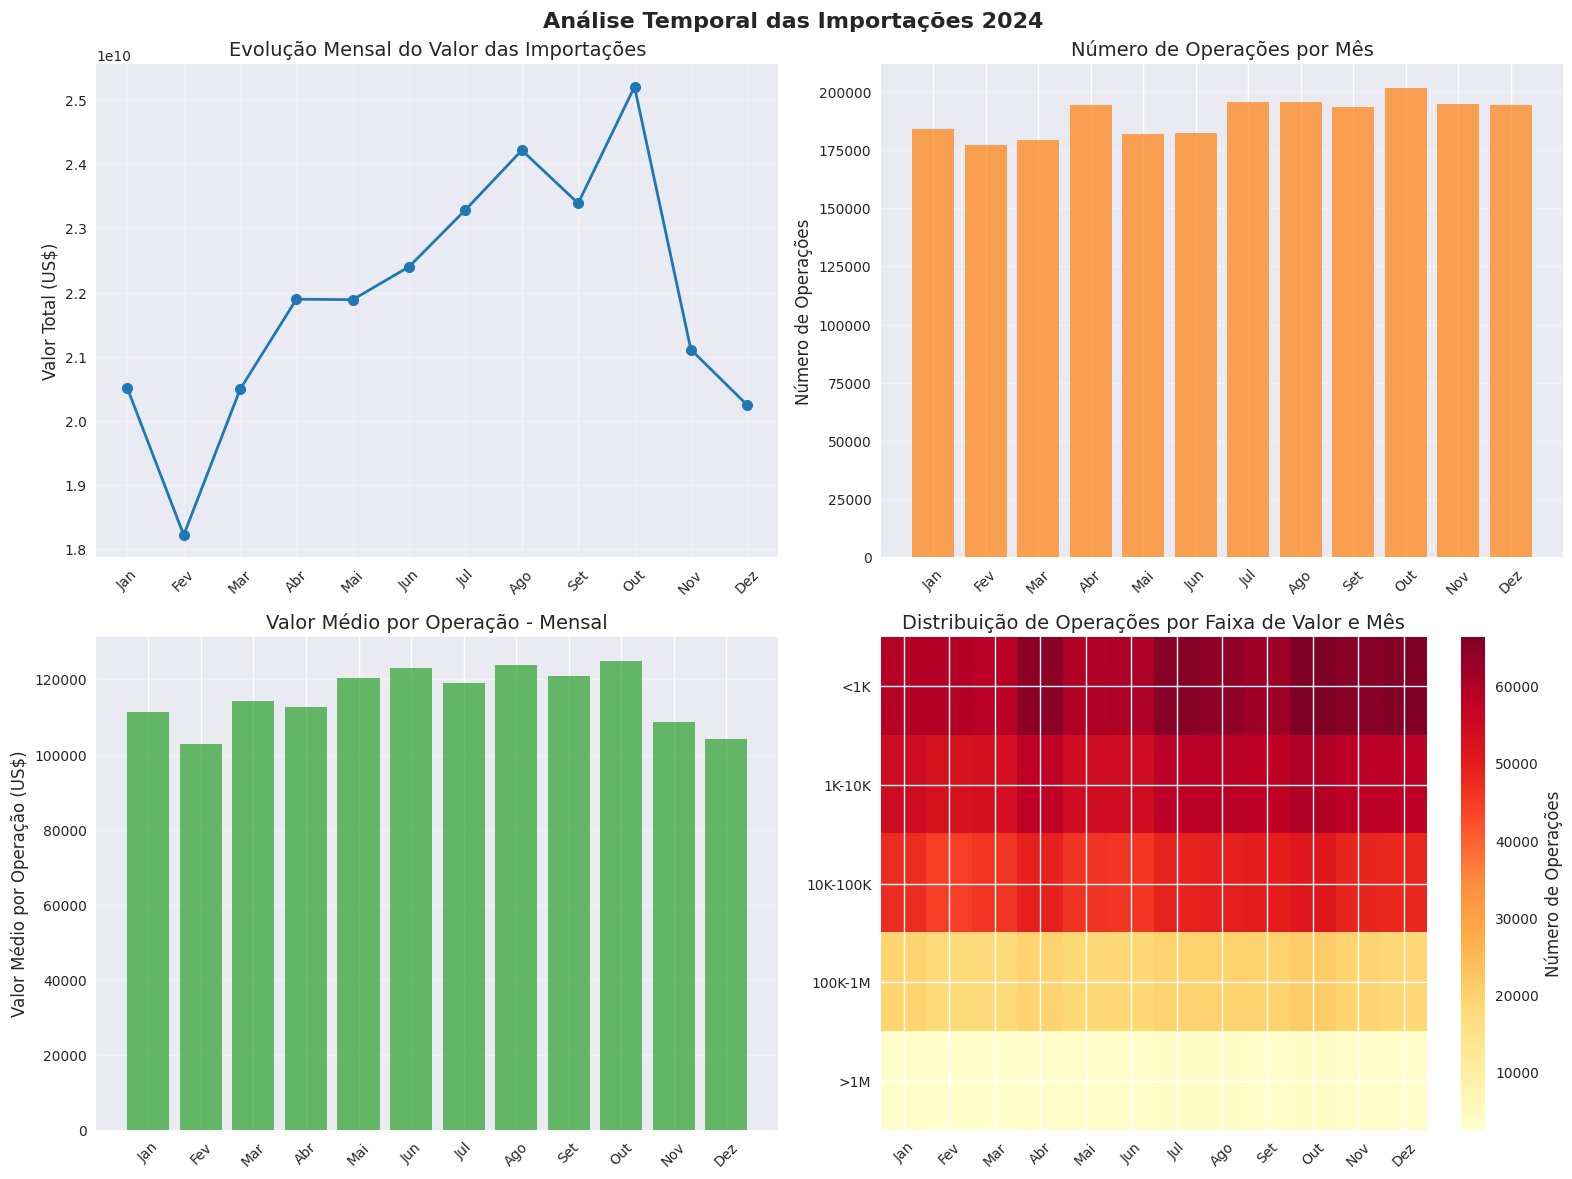


📊 ÍNDICES DE SAZONALIDADE
   📉 Jan: 93.6% da média anual
   📉 Fev: 83.2% da média anual
   📉 Mar: 93.5% da média anual
   📊 Abr: 100.0% da média anual
   📊 Mai: 99.9% da média anual
   📊 Jun: 102.3% da média anual
   📈 Jul: 106.3% da média anual
   📈 Ago: 110.6% da média anual
   📈 Set: 106.8% da média anual
   📈 Out: 115.1% da média anual
   📊 Nov: 96.4% da média anual
   📉 Dez: 92.4% da média anual
✅ Análise temporal concluída!


In [17]:
# 2. Análise Temporal Detalhada
if 'CO_MES' in df.columns and vl_col:
    print("\n📅 ANÁLISE TEMPORAL E SAZONALIDADE")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise Temporal das Importações 2024', fontsize=16, fontweight='bold')
    
    # Série temporal mensal
    monthly_values = df.groupby('CO_MES')[vl_col].sum()
    monthly_counts = df.groupby('CO_MES').size()
    
    month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                   'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
    
    ax1.plot(range(1, 13), monthly_values.values, marker='o', linewidth=2, markersize=8, color=colors[0])
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(month_names, rotation=45)
    ax1.set_ylabel('Valor Total (US$)')
    ax1.set_title('Evolução Mensal do Valor das Importações')
    ax1.grid(True, alpha=0.3)
    ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Número de operações por mês
    ax2.bar(range(1, 13), monthly_counts.values, color=colors[1], alpha=0.7)
    ax2.set_xticks(range(1, 13))
    ax2.set_xticklabels(month_names, rotation=45)
    ax2.set_ylabel('Número de Operações')
    ax2.set_title('Número de Operações por Mês')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Valor médio por operação por mês
    avg_value_monthly = monthly_values / monthly_counts
    ax3.bar(range(1, 13), avg_value_monthly.values, color=colors[2], alpha=0.7)
    ax3.set_xticks(range(1, 13))
    ax3.set_xticklabels(month_names, rotation=45)
    ax3.set_ylabel('Valor Médio por Operação (US$)')
    ax3.set_title('Valor Médio por Operação - Mensal')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Heatmap de concentração por mês e faixa de valor
    # Criar faixas de valor
    df_temp = df.copy()
    df_temp['Faixa_Valor'] = pd.cut(df_temp[vl_col], 
                                   bins=[0, 1000, 10000, 100000, 1000000, float('inf')],
                                   labels=['<1K', '1K-10K', '10K-100K', '100K-1M', '>1M'])
    
    heatmap_data = df_temp.groupby(['CO_MES', 'Faixa_Valor']).size().unstack(fill_value=0)
    
    im = ax4.imshow(heatmap_data.T.values, cmap='YlOrRd', aspect='auto')
    ax4.set_xticks(range(len(heatmap_data.index)))
    ax4.set_xticklabels([month_names[i-1] for i in heatmap_data.index], rotation=45)
    ax4.set_yticks(range(len(heatmap_data.columns)))
    ax4.set_yticklabels(heatmap_data.columns)
    ax4.set_title('Distribuição de Operações por Faixa de Valor e Mês')
    
    # Adicionar barra de cores
    cbar = plt.colorbar(im, ax=ax4)
    cbar.set_label('Número de Operações')
    
    plt.tight_layout()
    plt.show()
    
    # Estatísticas de sazonalidade
    print("\n📊 ÍNDICES DE SAZONALIDADE")
    seasonal_index = (monthly_values / monthly_values.mean()) * 100
    for month, index in zip(month_names, seasonal_index.values):
        status = "📈" if index > 105 else "📉" if index < 95 else "📊"
        print(f"   {status} {month}: {index:.1f}% da média anual")

print("✅ Análise temporal concluída!")

## 5. ANÁLISE DETALHADA DOS CÓDIGOS NCM

### 5.1 Estrutura Hierárquica da NCM e Padrões de Classificação

Esta seção analisa a estrutura hierárquica dos códigos NCM, identificando os capítulos, posições e subposições mais relevantes para o comércio exterior brasileiro.

🏷️ ANÁLISE HIERÁRQUICA DOS CÓDIGOS NCM
📊 ANÁLISE POR CAPÍTULOS NCM (2 primeiros dígitos)
--------------------------------------------------
TOP 20 CAPÍTULOS POR VALOR:


,VL_FOB_sum,VL_FOB_count,VL_FOB_mean,CO_NCM_nunique,QT_ESTAT_sum,Participacao_%,Participacao_Acum_%
Capitulo,,,,,,,
84,41120522967,471749,87166.11,1083,4431889607,15.64,15.64
27,34305919606,8409,4079666.98,63,36176924460,13.05,28.69
85,30995469813,418631,74040.07,628,118925212332,11.79,40.48
87,23050966874,81174,283969.83,145,1443211035,8.77,49.25
29,13914172164,95454,145768.35,1231,5226226924,5.29,54.54
31,13581411089,5805,2339605.70,33,44277703664,5.17,59.71
30,12345981512,15293,807296.25,208,60750348,4.70,64.41
39,11022815493,139683,78913.08,331,5728048391,4.19,68.60
90,8428406678,153472,54918.20,362,6699568635,3.21,71.81



💡 Insight: 13 capítulos representam 80% do valor total das importações

📈 DIVERSIDADE DE PRODUTOS POR CAPÍTULO
Capítulos com maior diversidade de códigos NCM:
   Capítulo 29: 1,231 códigos NCM únicos (US$ 13,914,172,164)
   Capítulo 84: 1,083 códigos NCM únicos (US$ 41,120,522,967)
   Capítulo 85: 628 códigos NCM únicos (US$ 30,995,469,813)
   Capítulo 28: 366 códigos NCM únicos (US$ 2,741,079,787)
   Capítulo 90: 362 códigos NCM únicos (US$ 8,428,406,678)
   Capítulo 39: 331 códigos NCM únicos (US$ 11,022,815,493)
   Capítulo 38: 216 códigos NCM únicos (US$ 7,447,437,864)
   Capítulo 72: 209 códigos NCM únicos (US$ 4,780,152,724)
   Capítulo 30: 208 códigos NCM únicos (US$ 12,345,981,512)
   Capítulo 48: 171 códigos NCM únicos (US$ 962,921,646)


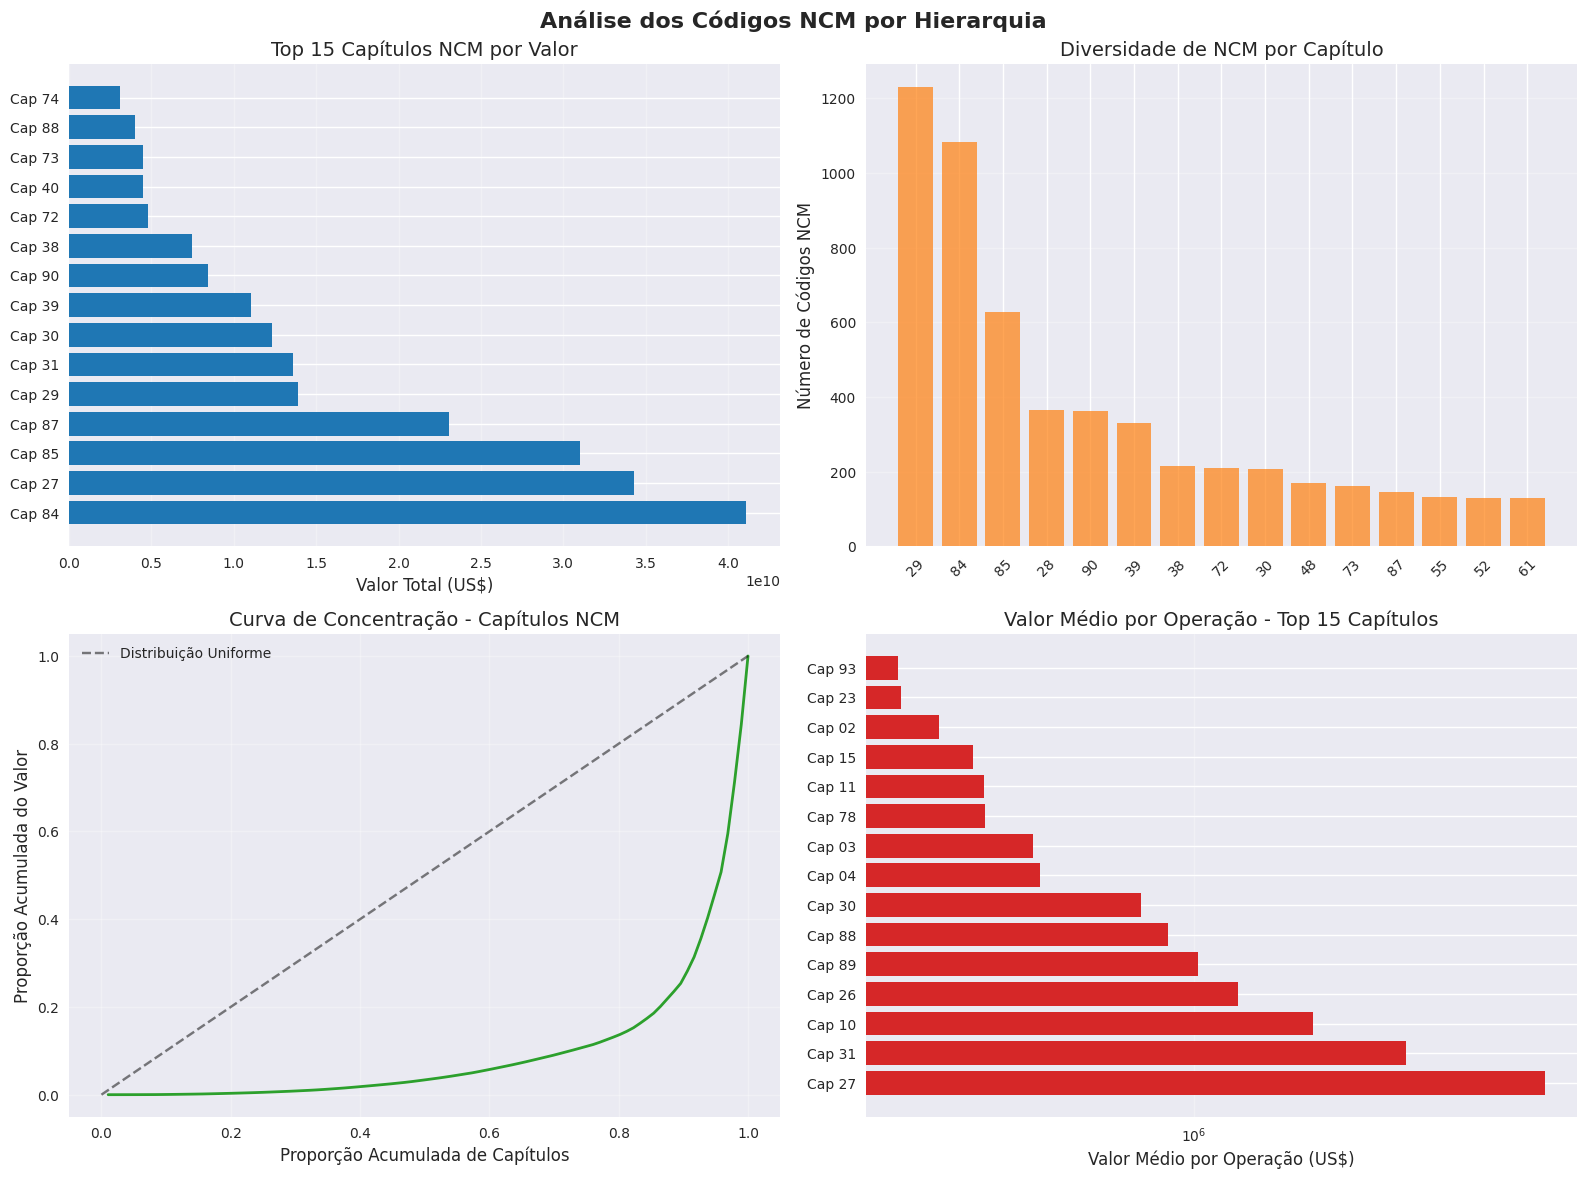

✅ Análise hierárquica dos códigos NCM concluída!


In [18]:
print("🏷️ ANÁLISE HIERÁRQUICA DOS CÓDIGOS NCM")
print("="*50)

if 'CO_NCM' in df.columns and vl_col:
    # Extrair componentes hierárquicos do código NCM
    df_ncm = df.copy()
    df_ncm['NCM_str'] = df_ncm['CO_NCM'].astype(str).str.zfill(8)
    
    # Extrair níveis hierárquicos
    df_ncm['Capitulo'] = df_ncm['NCM_str'].str[:2].astype(int)  # Primeiros 2 dígitos
    df_ncm['Posicao'] = df_ncm['NCM_str'].str[:4].astype(int)   # Primeiros 4 dígitos
    df_ncm['Subposicao'] = df_ncm['NCM_str'].str[:6].astype(int) # Primeiros 6 dígitos
    df_ncm['Item'] = df_ncm['NCM_str'].str[:7].astype(int)      # Primeiros 7 dígitos
    
    print("📊 ANÁLISE POR CAPÍTULOS NCM (2 primeiros dígitos)")
    print("-" * 50)
    
    # Análise por capítulos
    capitulos_analysis = df_ncm.groupby('Capitulo').agg({
        vl_col: ['sum', 'count', 'mean'],
        'CO_NCM': 'nunique',
        qt_col: 'sum' if qt_col else None
    }).round(2)
    
    # Flatten column names
    capitulos_analysis.columns = ['_'.join(col).strip() if col[1] else col[0] for col in capitulos_analysis.columns]
    capitulos_analysis = capitulos_analysis.sort_values(f'{vl_col}_sum', ascending=False)
    
    # Adicionar participação percentual
    total_value = df_ncm[vl_col].sum()
    capitulos_analysis['Participacao_%'] = (capitulos_analysis[f'{vl_col}_sum'] / total_value * 100).round(2)
    capitulos_analysis['Participacao_Acum_%'] = capitulos_analysis['Participacao_%'].cumsum().round(2)
    
    print("TOP 20 CAPÍTULOS POR VALOR:")
    display(capitulos_analysis.head(20))
    
    # Encontrar capítulos que representam 80% das importações
    capitulos_80 = capitulos_analysis[capitulos_analysis['Participacao_Acum_%'] <= 80]
    print(f"\n💡 Insight: {len(capitulos_80)} capítulos representam 80% do valor total das importações")
    
    # Análise de diversidade por capítulo
    print(f"\n📈 DIVERSIDADE DE PRODUTOS POR CAPÍTULO")
    diversidade = df_ncm.groupby('Capitulo')['CO_NCM'].nunique().sort_values(ascending=False).head(10)
    print("Capítulos com maior diversidade de códigos NCM:")
    for cap, count in diversidade.items():
        valor_cap = capitulos_analysis.loc[cap, f'{vl_col}_sum']
        print(f"   Capítulo {cap:02d}: {count:,} códigos NCM únicos (US$ {valor_cap:,.0f})")
    
    # Visualização dos principais capítulos
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise dos Códigos NCM por Hierarquia', fontsize=16, fontweight='bold')
    
    # Top 15 capítulos por valor
    top_caps = capitulos_analysis.head(15)
    ax1.barh(range(len(top_caps)), top_caps[f'{vl_col}_sum'], color=colors[0])
    ax1.set_yticks(range(len(top_caps)))
    ax1.set_yticklabels([f'Cap {cap:02d}' for cap in top_caps.index])
    ax1.set_xlabel('Valor Total (US$)')
    ax1.set_title('Top 15 Capítulos NCM por Valor')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Distribuição de códigos NCM por capítulo
    ncm_por_capitulo = df_ncm.groupby('Capitulo')['CO_NCM'].nunique().sort_values(ascending=False).head(15)
    ax2.bar(range(len(ncm_por_capitulo)), ncm_por_capitulo.values, color=colors[1], alpha=0.7)
    ax2.set_xticks(range(len(ncm_por_capitulo)))
    ax2.set_xticklabels([f'{cap:02d}' for cap in ncm_por_capitulo.index], rotation=45)
    ax2.set_ylabel('Número de Códigos NCM')
    ax2.set_title('Diversidade de NCM por Capítulo')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Curva de concentração (Lorenz)
    cap_values_sorted = capitulos_analysis[f'{vl_col}_sum'].sort_values()
    cumulative_values = cap_values_sorted.cumsum() / cap_values_sorted.sum()
    cumulative_caps = np.arange(1, len(cumulative_values) + 1) / len(cumulative_values)
    
    ax3.plot(cumulative_caps, cumulative_values, linewidth=2, color=colors[2])
    ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Distribuição Uniforme')
    ax3.set_xlabel('Proporção Acumulada de Capítulos')
    ax3.set_ylabel('Proporção Acumulada do Valor')
    ax3.set_title('Curva de Concentração - Capítulos NCM')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Valor médio por operação por capítulo (top 15)
    valor_medio = capitulos_analysis[f'{vl_col}_mean'].sort_values(ascending=False).head(15)
    ax4.barh(range(len(valor_medio)), valor_medio.values, color=colors[3])
    ax4.set_yticks(range(len(valor_medio)))
    ax4.set_yticklabels([f'Cap {cap:02d}' for cap in valor_medio.index])
    ax4.set_xlabel('Valor Médio por Operação (US$)')
    ax4.set_title('Valor Médio por Operação - Top 15 Capítulos')
    ax4.grid(True, alpha=0.3, axis='x')
    ax4.set_xscale('log')
    
    plt.tight_layout()
    plt.show()

print("✅ Análise hierárquica dos códigos NCM concluída!")

## 6. ANÁLISE GEOGRÁFICA E PARCERIAS COMERCIAIS

### 6.1 Distribuição Geográfica das Importações

Análise da origem geográfica das importações brasileiras, identificando principais parceiros comerciais e padrões de dependência.

🌍 ANÁLISE GEOGRÁFICA DAS IMPORTAÇÕES
🏆 TOP 20 PAÍSES FORNECEDORES:


,,VL_FOB_sum,VL_FOB_count,VL_FOB_mean,CO_NCM_nunique,QT_ESTAT_sum,Participacao_%,Participacao_Acum_%
CO_PAIS,NO_PAIS,,,,,,,
160,China,63636345571,510021,124772.01,6914,112670873663,24.21,24.21
249,Estados Unidos,40652417455,239664,169622.54,6295,27485951274,15.46,39.67
23,Alemanha,13783197105,179100,76958.11,5393,3671049404,5.24,44.91
63,Argentina,13577045088,28713,472853.59,1928,10005685743,5.16,50.07
676,Rússia,10965470014,2623,4180507.06,338,14146003494,4.17,54.24
361,Índia,6849930671,76095,90018.14,3950,2893976020,2.61,56.85
386,Itália,6388253879,130762,48854.05,4623,1079862071,2.43,59.28
275,França,6189845834,80581,76815.20,4083,716964399,2.35,61.63
493,México,5767276053,50983,113121.55,2261,1079799881,2.19,63.82



📊 ANÁLISE DE CONCENTRAÇÃO GEOGRÁFICA
   • 3 países representam 50% das importações
   • 20 países representam 80% das importações
   • 48 países representam 95% das importações
   • Total de países fornecedores: 239
   • Índice HHI para países: 954
   • Concentração geográfica: Baixa

🎯 ESPECIALIZAÇÃO DOS PRINCIPAIS PARCEIROS

   🇺🇳 China
      • Participação total: 24.2%
      • Top 3 NCMs representam: 8.6% das importações deste país
      • Diversidade: 6,914 códigos NCM diferentes

   🇺🇳 Estados Unidos
      • Participação total: 15.5%
      • Top 3 NCMs representam: 19.1% das importações deste país
      • Diversidade: 6,295 códigos NCM diferentes

   🇺🇳 Alemanha
      • Participação total: 5.2%
      • Top 3 NCMs representam: 10.2% das importações deste país
      • Diversidade: 5,393 códigos NCM diferentes

   🇺🇳 Argentina
      • Participação total: 5.2%
      • Top 3 NCMs representam: 36.2% das importações deste país
      • Diversidade: 1,928 códigos NCM diferentes

   🇺🇳 Rús

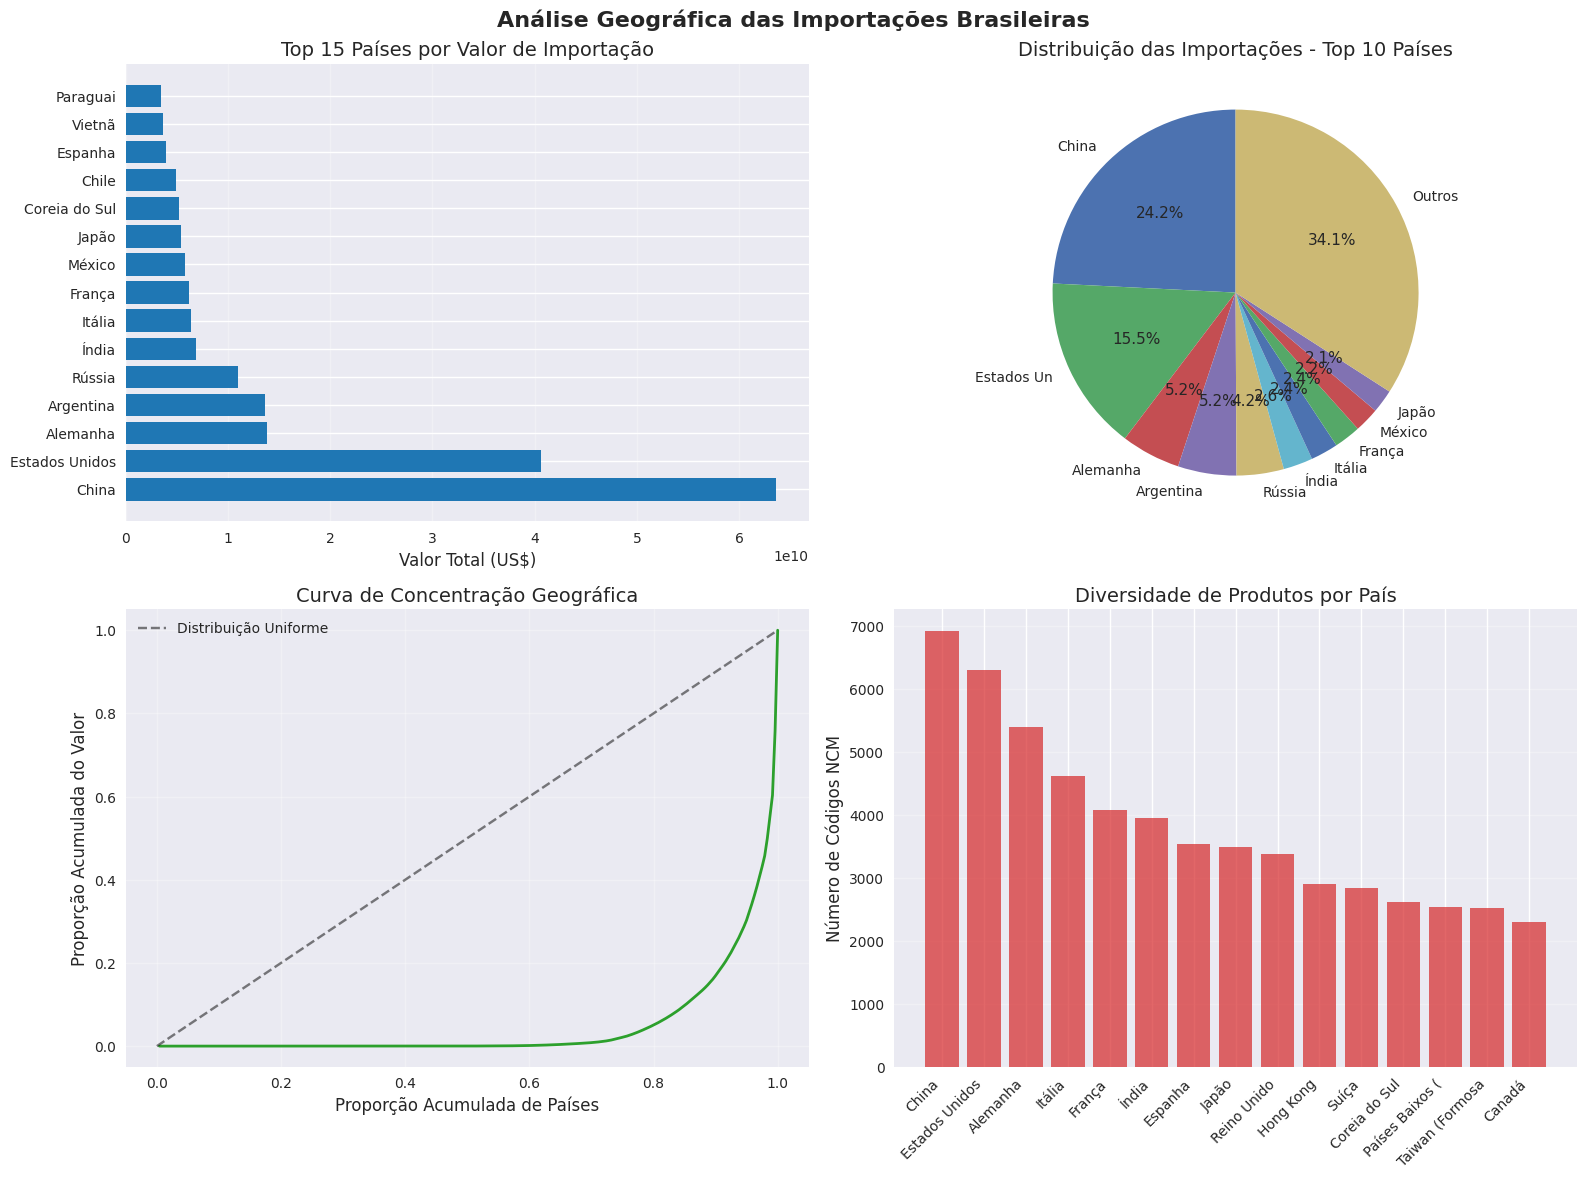

✅ Análise geográfica concluída!


In [19]:
print("🌍 ANÁLISE GEOGRÁFICA DAS IMPORTAÇÕES")
print("="*50)

if 'CO_PAIS' in df.columns and vl_col:
    # Análise detalhada por países
    paises_analysis = df.groupby(['CO_PAIS', 'NO_PAIS']).agg({
        vl_col: ['sum', 'count', 'mean'],
        'CO_NCM': 'nunique',
        qt_col: 'sum' if qt_col else None
    }).round(2)
    
    # Flatten column names
    paises_analysis.columns = ['_'.join(col).strip() if col[1] else col[0] for col in paises_analysis.columns]
    paises_analysis = paises_analysis.sort_values(f'{vl_col}_sum', ascending=False)
    
    # Adicionar participação percentual
    total_value = df[vl_col].sum()
    paises_analysis['Participacao_%'] = (paises_analysis[f'{vl_col}_sum'] / total_value * 100).round(2)
    paises_analysis['Participacao_Acum_%'] = paises_analysis['Participacao_%'].cumsum().round(2)
    
    print("🏆 TOP 20 PAÍSES FORNECEDORES:")
    display(paises_analysis.head(20))
    
    # Análise de concentração geográfica
    print(f"\n📊 ANÁLISE DE CONCENTRAÇÃO GEOGRÁFICA")
    
    # Países que representam diferentes percentuais
    paises_50 = len(paises_analysis[paises_analysis['Participacao_Acum_%'] <= 50])
    paises_80 = len(paises_analysis[paises_analysis['Participacao_Acum_%'] <= 80])
    paises_95 = len(paises_analysis[paises_analysis['Participacao_Acum_%'] <= 95])
    
    print(f"   • {paises_50} países representam 50% das importações")
    print(f"   • {paises_80} países representam 80% das importações") 
    print(f"   • {paises_95} países representam 95% das importações")
    print(f"   • Total de países fornecedores: {len(paises_analysis)}")
    
    # Índice de Herfindahl-Hirschman para países
    paises_shares = (paises_analysis[f'{vl_col}_sum'] / total_value) ** 2
    hhi_paises = paises_shares.sum() * 10000
    print(f"   • Índice HHI para países: {hhi_paises:.0f}")
    
    concentration_level = "Alta" if hhi_paises > 2500 else "Moderada" if hhi_paises > 1500 else "Baixa"
    print(f"   • Concentração geográfica: {concentration_level}")
    
    # Análise de especialização por país
    print(f"\n🎯 ESPECIALIZAÇÃO DOS PRINCIPAIS PARCEIROS")
    
    # Para os top 10 países, identificar seus principais produtos
    top_10_paises = paises_analysis.head(10).index
    
    for pais_code, pais_nome in top_10_paises:
        df_pais = df[df['CO_PAIS'] == pais_code]
        top_ncm_pais = df_pais.groupby('CO_NCM')[vl_col].sum().sort_values(ascending=False).head(3)
        
        # Calcular concentração dos top 3 NCMs para este país
        total_pais = df_pais[vl_col].sum()
        concentracao_top3 = (top_ncm_pais.sum() / total_pais * 100)
        
        print(f"\n   🇺🇳 {pais_nome}")
        print(f"      • Participação total: {paises_analysis.loc[(pais_code, pais_nome), 'Participacao_%']:.1f}%")
        print(f"      • Top 3 NCMs representam: {concentracao_top3:.1f}% das importações deste país")
        print(f"      • Diversidade: {df_pais['CO_NCM'].nunique():,} códigos NCM diferentes")
    
    # Visualizações geográficas
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise Geográfica das Importações Brasileiras', fontsize=16, fontweight='bold')
    
    # Top 15 países por valor
    top_paises_plot = paises_analysis.head(15)
    paises_names = [nome.split(',')[0][:15] if ',' in nome else nome[:15] for _, nome in top_paises_plot.index]
    
    ax1.barh(range(len(top_paises_plot)), top_paises_plot[f'{vl_col}_sum'], color=colors[0])
    ax1.set_yticks(range(len(top_paises_plot)))
    ax1.set_yticklabels(paises_names)
    ax1.set_xlabel('Valor Total (US$)')
    ax1.set_title('Top 15 Países por Valor de Importação')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Participação percentual - gráfico de pizza dos top 10
    top_10_values = paises_analysis.head(10)[f'{vl_col}_sum']
    outros = total_value - top_10_values.sum()
    
    pie_values = list(top_10_values.values) + [outros]
    pie_labels = [nome.split(',')[0][:10] for _, nome in paises_analysis.head(10).index] + ['Outros']
    
    ax2.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribuição das Importações - Top 10 Países')
    
    # Curva de concentração geográfica
    pais_values_sorted = paises_analysis[f'{vl_col}_sum'].sort_values()
    cumulative_values = pais_values_sorted.cumsum() / pais_values_sorted.sum()
    cumulative_paises = np.arange(1, len(cumulative_values) + 1) / len(cumulative_values)
    
    ax3.plot(cumulative_paises, cumulative_values, linewidth=2, color=colors[2])
    ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Distribuição Uniforme')
    ax3.set_xlabel('Proporção Acumulada de Países')
    ax3.set_ylabel('Proporção Acumulada do Valor')
    ax3.set_title('Curva de Concentração Geográfica')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Diversidade de produtos por país (top 15)
    diversidade_paises = df.groupby('CO_PAIS')['CO_NCM'].nunique().sort_values(ascending=False).head(15)
    
    # Mapear nomes dos países
    pais_map = dict(zip(paises_analysis.index.get_level_values(0), 
                       paises_analysis.index.get_level_values(1)))
    diversidade_names = [pais_map.get(code, f'País {code}')[:15] for code in diversidade_paises.index]
    
    ax4.bar(range(len(diversidade_paises)), diversidade_paises.values, color=colors[3], alpha=0.7)
    ax4.set_xticks(range(len(diversidade_paises)))
    ax4.set_xticklabels(diversidade_names, rotation=45, ha='right')
    ax4.set_ylabel('Número de Códigos NCM')
    ax4.set_title('Diversidade de Produtos por País')
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

print("✅ Análise geográfica concluída!")

## 7. DETECÇÃO DE ANOMALIAS E PADRÕES INCOMUNS

### 7.1 Identificação de Outliers e Comportamentos Atípicos

Análise estatística para identificar operações anômalas, valores extremos e padrões incomuns que podem indicar erros de dados ou situações especiais.

🚨 DETECÇÃO DE ANOMALIAS E OUTLIERS

📊 1. ANÁLISE ESTATÍSTICA DE OUTLIERS
   • Método IQR:
     - Q1: US$ 495.00
     - Q3: US$ 27,040.00
     - IQR: US$ 26,545.00
     - Limite inferior: US$ -39,322.50
     - Limite superior: US$ 66,857.50
     - Outliers identificados: 346,012 (15.22%)

   • Método Z-Score (|z| > 3):
     - Outliers identificados: 6,739 (0.30%)

💎 2. VALORES EXTREMOS

   📈 TOP 10 MAIORES OPERAÇÕES:
      1. NCM 87036000 | China | US$ 545,738,786.00 | Mês 6
      2. NCM 27111100 | Estados Unidos | US$ 418,544,007.00 | Mês 5
      3. NCM 84111200 | Estados Unidos | US$ 282,214,052.00 | Mês 10
      4. NCM 27090010 | Arábia Saudita | US$ 280,357,244.00 | Mês 8
      5. NCM 84111200 | Estados Unidos | US$ 277,230,470.00 | Mês 5
      6. NCM 87038000 | China | US$ 268,385,540.00 | Mês 6
      7. NCM 84119100 | Estados Unidos | US$ 264,539,557.00 | Mês 11
      8. NCM 84119100 | Estados Unidos | US$ 260,704,510.00 | Mês 8
      9. NCM 84119100 | Estados Unidos | US$ 253,827

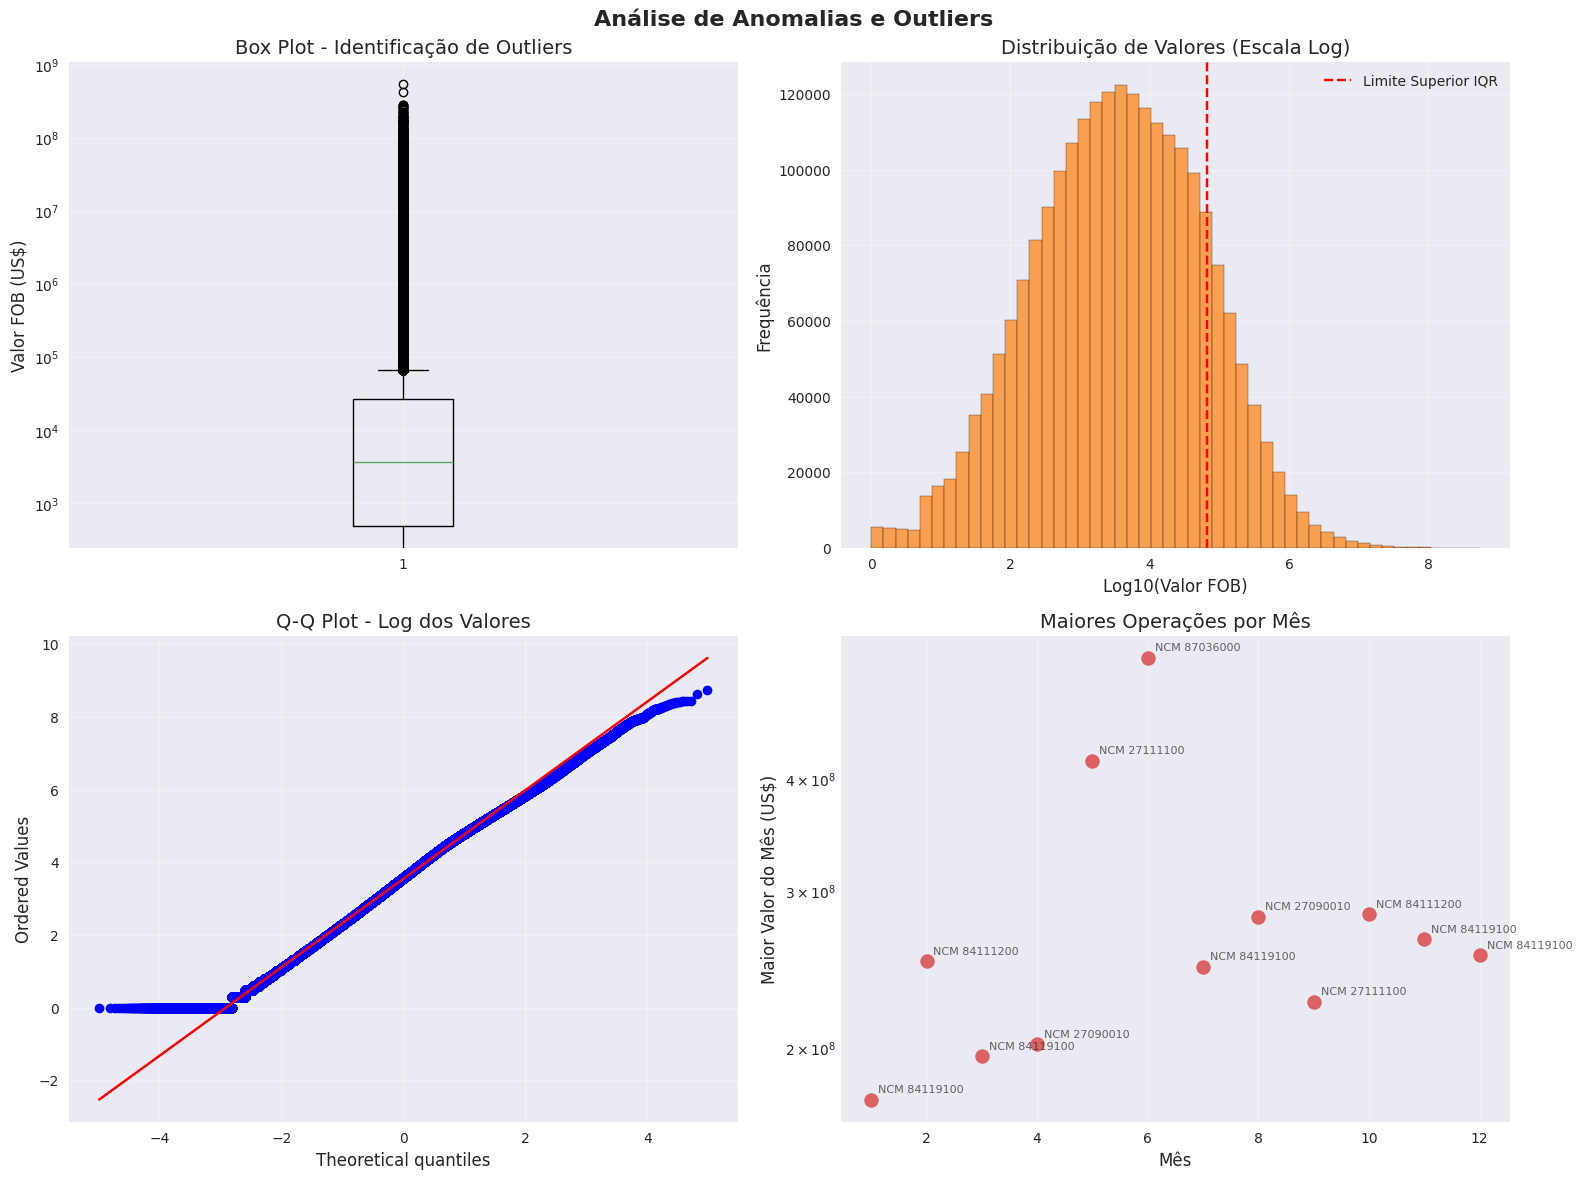

✅ Análise de anomalias concluída!


In [20]:
print("🚨 DETECÇÃO DE ANOMALIAS E OUTLIERS")
print("="*50)

if vl_col:
    # 1. Análise de outliers por método estatístico
    print("\n📊 1. ANÁLISE ESTATÍSTICA DE OUTLIERS")
    
    # Método IQR (Interquartile Range)
    Q1 = df[vl_col].quantile(0.25)
    Q3 = df[vl_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr = df[(df[vl_col] < lower_bound) | (df[vl_col] > upper_bound)]
    
    print(f"   • Método IQR:")
    print(f"     - Q1: US$ {Q1:,.2f}")
    print(f"     - Q3: US$ {Q3:,.2f}")
    print(f"     - IQR: US$ {IQR:,.2f}")
    print(f"     - Limite inferior: US$ {lower_bound:,.2f}")
    print(f"     - Limite superior: US$ {upper_bound:,.2f}")
    print(f"     - Outliers identificados: {len(outliers_iqr):,} ({len(outliers_iqr)/len(df)*100:.2f}%)")
    
    # Método Z-Score
    from scipy import stats
    z_scores = np.abs(stats.zscore(df[vl_col]))
    outliers_zscore = df[z_scores > 3]
    
    print(f"\n   • Método Z-Score (|z| > 3):")
    print(f"     - Outliers identificados: {len(outliers_zscore):,} ({len(outliers_zscore)/len(df)*100:.2f}%)")
    
    # 2. Análise de valores extremos
    print(f"\n💎 2. VALORES EXTREMOS")
    
    # Top 10 maiores operações
    top_operations = df.nlargest(10, vl_col)
    print(f"\n   📈 TOP 10 MAIORES OPERAÇÕES:")
    
    for i, (idx, row) in enumerate(top_operations.iterrows(), 1):
        ncm = row.get('CO_NCM', 'N/A')
        pais = row.get('NO_PAIS', row.get('CO_PAIS', 'N/A'))
        valor = row[vl_col]
        mes = row.get('CO_MES', 'N/A')
        
        print(f"     {i:2d}. NCM {ncm} | {pais} | US$ {valor:,.2f} | Mês {mes}")
    
    # Verificar operações com valores suspeitos
    print(f"\n   ⚠️ OPERAÇÕES POTENCIALMENTE SUSPEITAS:")
    
    # Valores muito baixos (< $1)
    very_low = df[df[vl_col] < 1]
    print(f"     • Valores < US$ 1: {len(very_low):,} operações")
    
    # Valores muito altos (> P99.9)
    p999 = df[vl_col].quantile(0.999)
    very_high = df[df[vl_col] > p999]
    print(f"     • Valores > P99.9 (US$ {p999:,.2f}): {len(very_high):,} operações")
    
    # Valores exatos (terminados em muitos zeros)
    exact_values = df[df[vl_col] % 1000 == 0]
    print(f"     • Valores 'redondos' (múltiplos de 1000): {len(exact_values):,} operações")
    
    # 3. Análise de padrões temporais anômalos
    if 'CO_MES' in df.columns:
        print(f"\n📅 3. PADRÕES TEMPORAIS ANÔMALOS")
        
        # Variação mensal extrema
        monthly_stats = df.groupby('CO_MES')[vl_col].agg(['sum', 'mean', 'count', 'std'])
        monthly_cv = monthly_stats['std'] / monthly_stats['mean']  # Coeficiente de variação
        
        print(f"   • Mês com maior variabilidade: {monthly_cv.idxmax()} (CV: {monthly_cv.max():.2f})")
        print(f"   • Mês com menor variabilidade: {monthly_cv.idxmin()} (CV: {monthly_cv.min():.2f})")
        
        # Detectar picos mensais
        monthly_totals = monthly_stats['sum']
        monthly_mean = monthly_totals.mean()
        monthly_std = monthly_totals.std()
        
        anomalous_months = monthly_totals[np.abs(monthly_totals - monthly_mean) > 2 * monthly_std]
        if len(anomalous_months) > 0:
            print(f"   • Meses com valores anômalos (>2σ da média):")
            for mes, valor in anomalous_months.items():
                deviation = (valor - monthly_mean) / monthly_std
                print(f"     - Mês {mes}: US$ {valor:,.0f} ({deviation:+.1f}σ)")
    
    # 4. Análise por NCM/País combinações anômalas
    print(f"\n🔍 4. COMBINAÇÕES NCM-PAÍS ANÔMALAS")
    
    if 'CO_PAIS' in df.columns and 'CO_NCM' in df.columns:
        # Identificar NCMs que vêm predominantemente de um só país
        ncm_country_analysis = df.groupby('CO_NCM').agg({
            'CO_PAIS': ['nunique', lambda x: x.mode().iloc[0] if len(x) > 0 else None],
            vl_col: 'sum'
        })
        
        ncm_country_analysis.columns = ['num_paises', 'pais_principal', 'valor_total']
        
        # NCMs que vêm de apenas 1 país mas têm alto valor
        monopoly_ncms = ncm_country_analysis[
            (ncm_country_analysis['num_paises'] == 1) & 
            (ncm_country_analysis['valor_total'] > ncm_country_analysis['valor_total'].quantile(0.95))
        ].sort_values('valor_total', ascending=False)
        
        print(f"   • NCMs de alto valor com fornecedor único: {len(monopoly_ncms)}")
        if len(monopoly_ncms) > 0:
            print(f"     Top 5:")
            for ncm, row in monopoly_ncms.head().iterrows():
                print(f"       NCM {ncm}: País {row['pais_principal']} | US$ {row['valor_total']:,.0f}")
    
    # Visualização das anomalias
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise de Anomalias e Outliers', fontsize=16, fontweight='bold')
    
    # Box plot para identificar outliers
    ax1.boxplot(df[vl_col], vert=True)
    ax1.set_ylabel('Valor FOB (US$)')
    ax1.set_title('Box Plot - Identificação de Outliers')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    
    # Histograma log-scale para ver distribuição
    ax2.hist(np.log10(df[vl_col][df[vl_col] > 0]), bins=50, alpha=0.7, color=colors[1], edgecolor='black')
    ax2.axvline(np.log10(upper_bound), color='red', linestyle='--', label=f'Limite Superior IQR')
    ax2.set_xlabel('Log10(Valor FOB)')
    ax2.set_ylabel('Frequência')
    ax2.set_title('Distribuição de Valores (Escala Log)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Q-Q plot para normalidade
    stats.probplot(np.log10(df[vl_col][df[vl_col] > 0]), dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot - Log dos Valores')
    ax3.grid(True, alpha=0.3)
    
    # Scatter plot dos maiores valores por mês
    if 'CO_MES' in df.columns:
        top_by_month = df.loc[df.groupby('CO_MES')[vl_col].idxmax()]
        ax4.scatter(top_by_month['CO_MES'], top_by_month[vl_col], 
                   c=colors[3], s=100, alpha=0.7)
        ax4.set_xlabel('Mês')
        ax4.set_ylabel('Maior Valor do Mês (US$)')
        ax4.set_title('Maiores Operações por Mês')
        ax4.set_yscale('log')
        ax4.grid(True, alpha=0.3)
        
        # Adicionar anotações para valores extremos
        for _, row in top_by_month.iterrows():
            if row[vl_col] > df[vl_col].quantile(0.999):
                ax4.annotate(f'NCM {row.get("CO_NCM", "")}', 
                           (row['CO_MES'], row[vl_col]), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

print("✅ Análise de anomalias concluída!")

## 8. INSIGHTS ESTRATÉGICOS E CONCLUSÕES

### 8.1 Síntese dos Principais Achados

Esta seção consolida os principais insights identificados na análise exploratória, fornecendo uma visão estratégica das importações brasileiras por NCM em 2024.

In [21]:
print("🎯 INSIGHTS ESTRATÉGICOS E CONCLUSÕES")
print("="*55)

# Consolidar métricas-chave para insights
if vl_col and 'CO_NCM' in df.columns and 'CO_PAIS' in df.columns:
    
    # Métricas consolidadas
    total_value = df[vl_col].sum()
    total_operations = len(df)
    unique_ncm = df['CO_NCM'].nunique()
    unique_countries = df['CO_PAIS'].nunique()
    avg_operation_value = df[vl_col].mean()
    
    print("📊 RESUMO EXECUTIVO")
    print("-" * 30)
    print(f"💰 Valor Total Importado: US$ {total_value:,.0f}")
    print(f"📦 Total de Operações: {total_operations:,}")
    print(f"🏷️ Códigos NCM Únicos: {unique_ncm:,}")
    print(f"🌍 Países Fornecedores: {unique_countries:,}")
    print(f"💵 Valor Médio por Operação: US$ {avg_operation_value:,.2f}")
    
    # Insights de concentração
    print(f"\n🎯 INSIGHTS DE CONCENTRAÇÃO")
    print("-" * 35)
    
    # Top NCMs
    top_ncm_10 = df.groupby('CO_NCM')[vl_col].sum().sort_values(ascending=False).head(10)
    concentration_ncm_10 = (top_ncm_10.sum() / total_value) * 100
    
    print(f"• Os top 10 códigos NCM representam {concentration_ncm_10:.1f}% do valor total")
    
    # Top países
    top_countries_10 = df.groupby('CO_PAIS')[vl_col].sum().sort_values(ascending=False).head(10)
    concentration_countries_10 = (top_countries_10.sum() / total_value) * 100
    
    print(f"• Os top 10 países representam {concentration_countries_10:.1f}% do valor total")
    
    # Capítulos mais importantes
    df_temp = df.copy()
    df_temp['Capitulo'] = df_temp['CO_NCM'].astype(str).str.zfill(8).str[:2].astype(int)
    top_chapters = df_temp.groupby('Capitulo')[vl_col].sum().sort_values(ascending=False).head(5)
    
    print(f"• Top 5 capítulos NCM: {list(top_chapters.index)}")
    
    # Insights temporais
    if 'CO_MES' in df.columns:
        print(f"\n📅 INSIGHTS TEMPORAIS")
        print("-" * 25)
        
        monthly_values = df.groupby('CO_MES')[vl_col].sum()
        best_month = monthly_values.idxmax()
        worst_month = monthly_values.idxmin()
        
        month_names = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 
                      5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto',
                      9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}
        
        print(f"• Maior mês de importações: {month_names[best_month]} (US$ {monthly_values[best_month]:,.0f})")
        print(f"• Menor mês de importações: {month_names[worst_month]} (US$ {monthly_values[worst_month]:,.0f})")
        
        # Sazonalidade
        cv_monthly = monthly_values.std() / monthly_values.mean()
        sazonalidade = "Alta" if cv_monthly > 0.3 else "Moderada" if cv_monthly > 0.15 else "Baixa"
        print(f"• Sazonalidade: {sazonalidade} (CV: {cv_monthly:.2f})")
    
    # Insights de dependência
    print(f"\n⚠️ INSIGHTS DE DEPENDÊNCIA E RISCO")
    print("-" * 40)
    
    # Dependência por país
    main_supplier = top_countries_10.index[0]
    main_supplier_share = (top_countries_10.iloc[0] / total_value) * 100
    
    print(f"• Principal fornecedor: País {main_supplier} ({main_supplier_share:.1f}% do total)")
    
    # NCMs com fornecedor único
    ncm_suppliers = df.groupby('CO_NCM')['CO_PAIS'].nunique()
    single_supplier_ncms = (ncm_suppliers == 1).sum()
    single_supplier_value = df[df['CO_NCM'].isin(ncm_suppliers[ncm_suppliers == 1].index)][vl_col].sum()
    single_supplier_share = (single_supplier_value / total_value) * 100
    
    print(f"• NCMs com fornecedor único: {single_supplier_ncms:,} ({single_supplier_share:.1f}% do valor)")
    
    # Insights de eficiência
    print(f"\n⚡ INSIGHTS DE EFICIÊNCIA")
    print("-" * 30)
    
    # Valor médio por operação por país
    avg_by_country = df.groupby('CO_PAIS')[vl_col].mean().sort_values(ascending=False)
    efficient_suppliers = avg_by_country.head(5)
    
    print(f"• Países com maior valor médio por operação:")
    for i, (country, avg_val) in enumerate(efficient_suppliers.head(3).items(), 1):
        print(f"  {i}. País {country}: US$ {avg_val:,.0f}")
    
    # Recomendações estratégicas
    print(f"\n🚀 RECOMENDAÇÕES ESTRATÉGICAS")
    print("-" * 40)
    
    recommendations = []
    
    if concentration_countries_10 > 70:
        recommendations.append("• Considerar diversificação geográfica para reduzir dependência")
    
    if single_supplier_share > 20:
        recommendations.append("• Mapear fornecedores alternativos para NCMs críticos")
    
    if concentration_ncm_10 > 50:
        recommendations.append("• Analisar oportunidades de substituição para produtos concentrados")
    
    # Análise de sazonalidade
    if 'CO_MES' in df.columns and cv_monthly > 0.2:
        recommendations.append("• Implementar estratégias para suavizar variações sazonais")
    
    # Análise de preços
    high_value_operations = (df[vl_col] > df[vl_col].quantile(0.95)).sum()
    if high_value_operations / total_operations > 0.1:
        recommendations.append("• Revisar operações de alto valor para otimização de custos")
    
    if not recommendations:
        recommendations.append("• Manter estratégia atual com monitoramento contínuo")
    
    for rec in recommendations:
        print(rec)
    
    # Métricas de benchmarking
    print(f"\n📈 MÉTRICAS DE PERFORMANCE")
    print("-" * 35)
    
    # Gini coefficient para concentração
    def gini_coefficient(values):
        sorted_values = np.sort(values)
        n = len(values)
        cum_values = np.cumsum(sorted_values)
        return (n + 1 - 2 * np.sum(cum_values) / cum_values[-1]) / n
    
    gini_ncm = gini_coefficient(df.groupby('CO_NCM')[vl_col].sum().values)
    gini_countries = gini_coefficient(df.groupby('CO_PAIS')[vl_col].sum().values)
    
    print(f"• Índice Gini - Concentração NCM: {gini_ncm:.3f}")
    print(f"• Índice Gini - Concentração Países: {gini_countries:.3f}")
    print(f"• Diversidade Shannon - NCM: {-np.sum((top_ncm_10/top_ncm_10.sum()) * np.log(top_ncm_10/top_ncm_10.sum())):.2f}")
    
    # Crescimento potencial
    underutilized_countries = df.groupby('CO_PAIS').agg({
        vl_col: 'sum',
        'CO_NCM': 'nunique'
    }).sort_values('CO_NCM', ascending=False).head(10)
    
    potential_countries = underutilized_countries[underutilized_countries[vl_col] < underutilized_countries[vl_col].median()]
    
    if len(potential_countries) > 0:
        print(f"\n🌱 OPORTUNIDADES DE CRESCIMENTO")
        print("-" * 40)
        print(f"• Países com alta diversidade mas baixo volume:")
        for country in potential_countries.head(3).index:
            ncm_count = underutilized_countries.loc[country, 'CO_NCM']
            value = underutilized_countries.loc[country, vl_col]
            print(f"  - País {country}: {ncm_count} NCMs diferentes, US$ {value:,.0f}")

print(f"\n✅ ANÁLISE EXPLORATÓRIA CONCLUÍDA!")
print("="*55)
print("📋 Relatório completo de EDA das Importações NCM 2024 gerado com sucesso!")
print("🔍 Utilize os insights acima para tomada de decisões estratégicas.")

🎯 INSIGHTS ESTRATÉGICOS E CONCLUSÕES
📊 RESUMO EXECUTIVO
------------------------------
💰 Valor Total Importado: US$ 262,869,606,174
📦 Total de Operações: 2,273,708
🏷️ Códigos NCM Únicos: 8,748
🌍 Países Fornecedores: 239
💵 Valor Médio por Operação: US$ 115,612.74

🎯 INSIGHTS DE CONCENTRAÇÃO
-----------------------------------
• Os top 10 códigos NCM representam 16.6% do valor total
• Os top 10 países representam 65.9% do valor total
• Top 5 capítulos NCM: [84, 27, 85, 87, 29]

📅 INSIGHTS TEMPORAIS
-------------------------
• Maior mês de importações: Outubro (US$ 25,209,647,872)
• Menor mês de importações: Fevereiro (US$ 18,217,925,231)
• Sazonalidade: Baixa (CV: 0.09)

⚠️ INSIGHTS DE DEPENDÊNCIA E RISCO
----------------------------------------
• Principal fornecedor: País 160 (24.2% do total)
• NCMs com fornecedor único: 831 (0.9% do valor)

⚡ INSIGHTS DE EFICIÊNCIA
------------------------------
• Países com maior valor médio por operação:
  1. País 281: US$ 59,071,408
  2. País 40: U